In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance

from sklearn.ensemble import AdaBoostClassifier

In [2]:
df=pd.read_csv("C:\\Users\\Saksham Kaushik\\Downloads\\archive (4)\\creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: Class, dtype: float64


<Axes: ylabel='Class'>

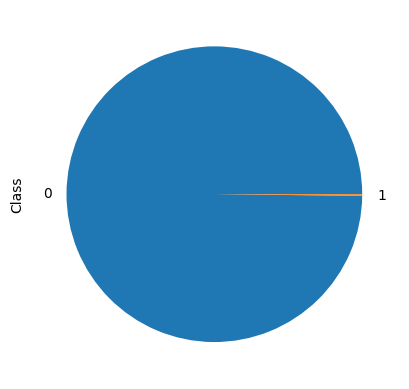

In [8]:
# Checking the class distribution of the target variable in percentage
print((df.groupby('Class')['Class'].count() / df['Class'].count()) * 100)

((df.groupby('Class')['Class'].count() / df['Class'].count()) * 100).plot.pie()

In [9]:
# Checking the % distribution of normal vs fraud
classes = df['Class'].value_counts()

normal_share = classes[0] / df['Class'].count() * 100
fraud_share = classes[1] / df['Class'].count() * 100

print(normal_share)
print(fraud_share)

99.82725143693798
0.1727485630620034


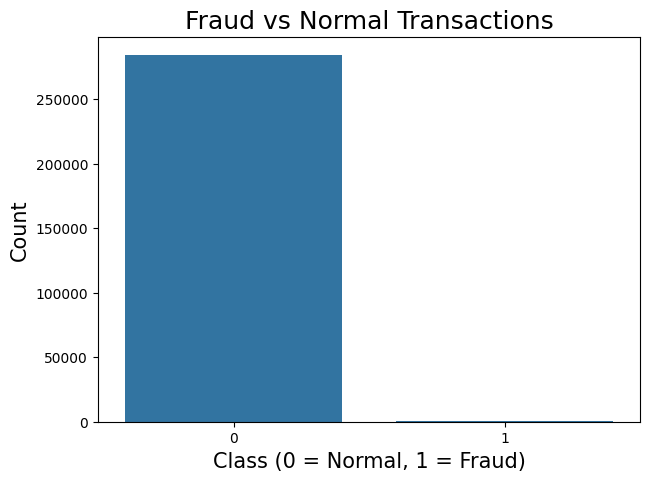

In [10]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transactions
plt.figure(figsize=(7,5))
sns.countplot(x='Class', data=df)

plt.title("Fraud vs Normal Transactions", fontsize=18)
plt.xlabel("Class (0 = Normal, 1 = Fraud)", fontsize=15)
plt.ylabel("Count", fontsize=15)

plt.show()

In [11]:
corr=df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


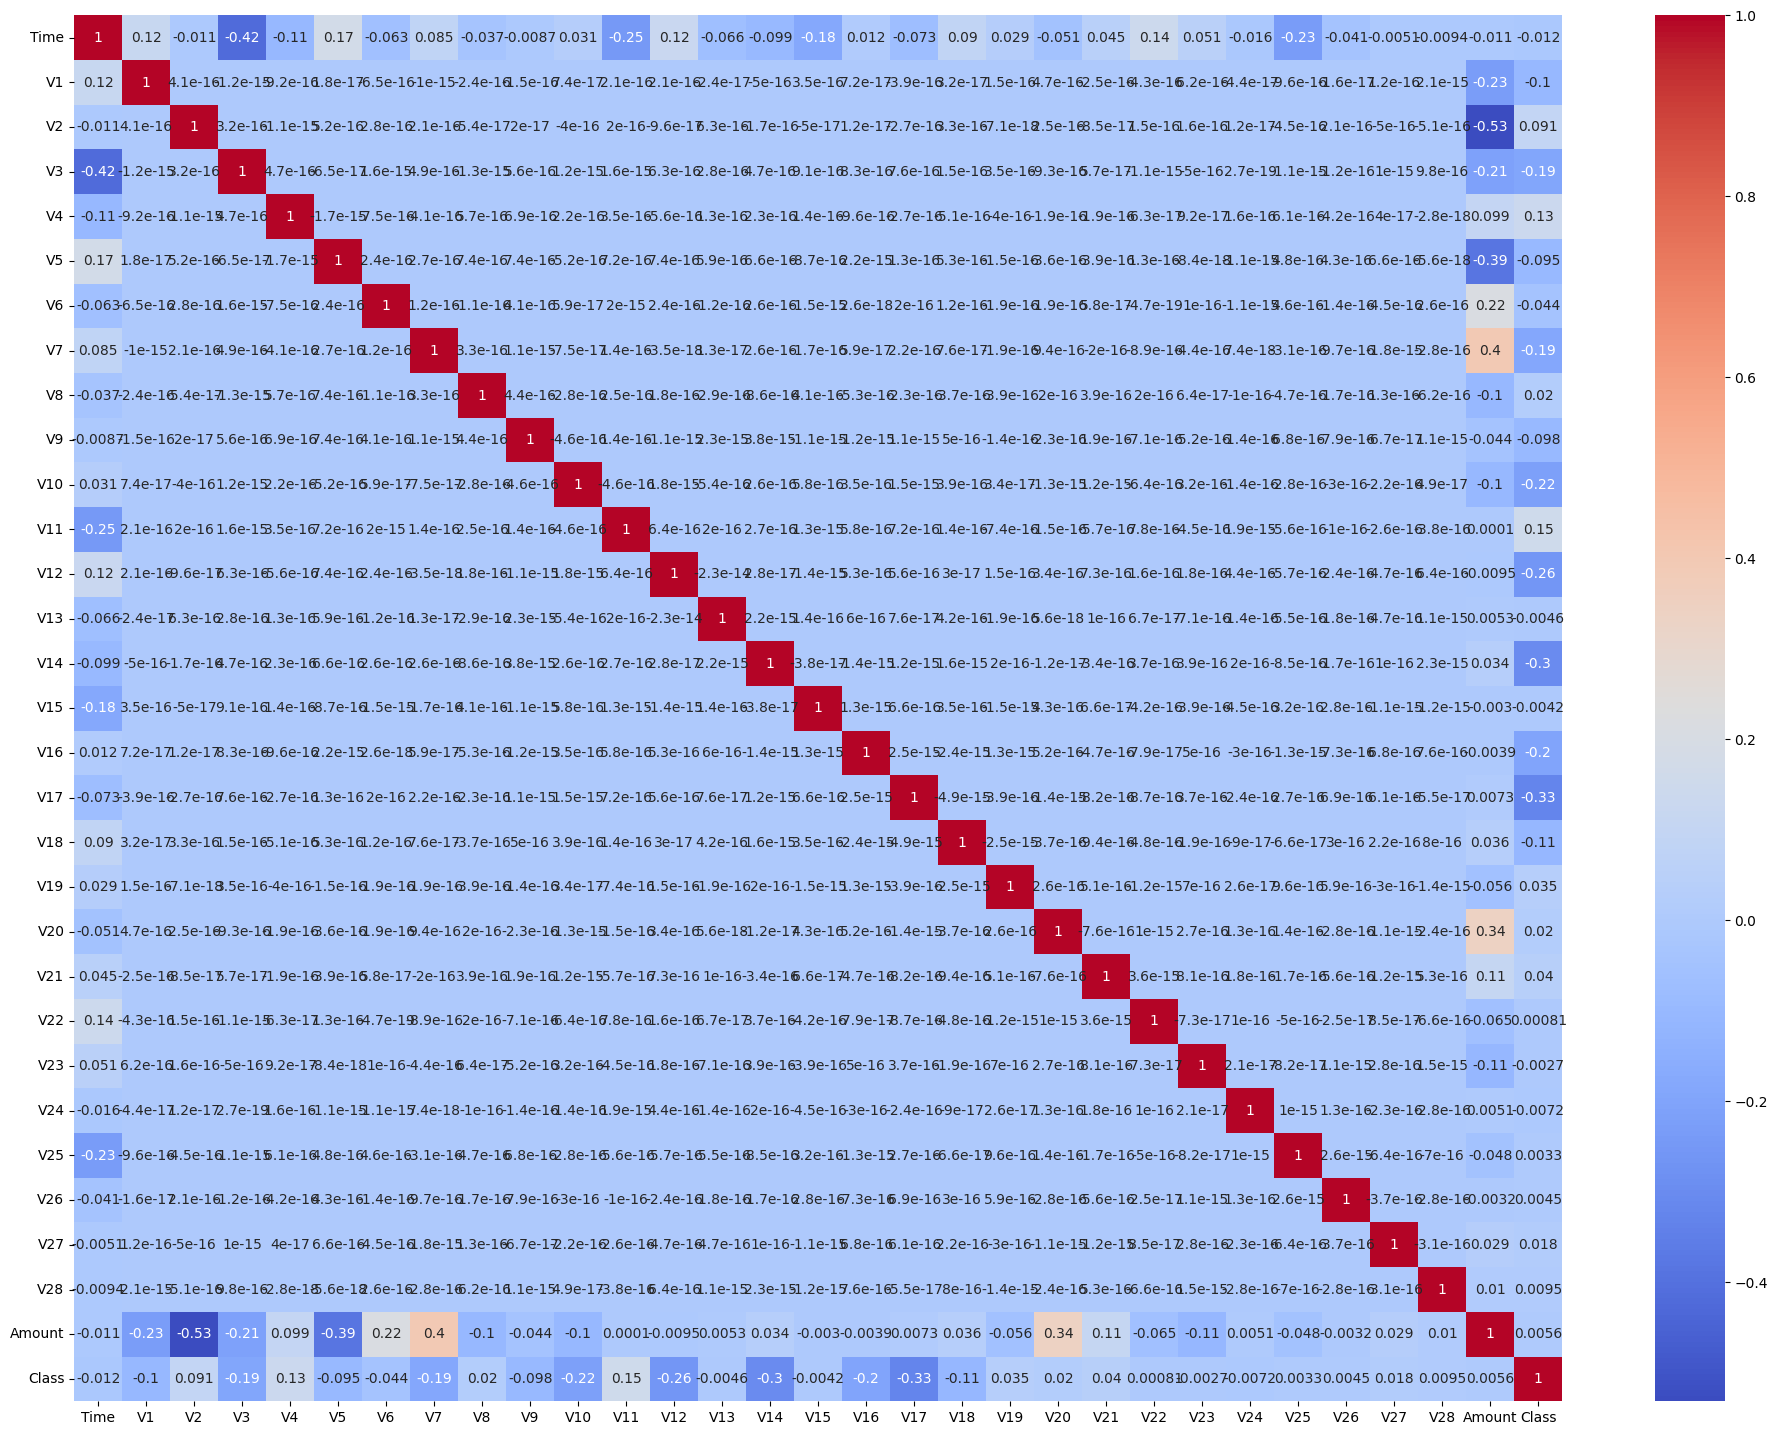

In [12]:
plt.figure(figsize=(24,18))

sns.heatmap(corr,cmap="coolwarm", annot=True)
plt.show()

In [13]:
# As time is given in relative fashion, we are using pandas.Timedelta
Delta_Time = pd.to_timedelta(df['Time'], unit='s')

# Create derived columns Mins and Hours
df['Time_Day'] = (Delta_Time.dt.components.days).astype(int)
df['Time_Hour'] = (Delta_Time.dt.components.hours).astype(int)
df['Time_Min'] = (Delta_Time.dt.components.minutes).astype(int)

In [14]:
# We will drop Time, as we have derived the Day/Hour/Minutes from the time column
df.drop('Time', axis=1, inplace=True)

# We will keep only derived column hour, as day/minutes might not be very useful
df.drop(['Time_Day', 'Time_Min'], axis=1, inplace=True)

## Splitting data into train & test

In [15]:
y= df['Class']
X= df.drop(['Class'], axis=1)

In [16]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Time_Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=100, test_size=0.20)

In [19]:
# Checking the spread of data post split
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
396
96


## Plotting the distribution of a variable

In [20]:
# Accumulating all the column names under one variable
cols = list(X.columns.values)

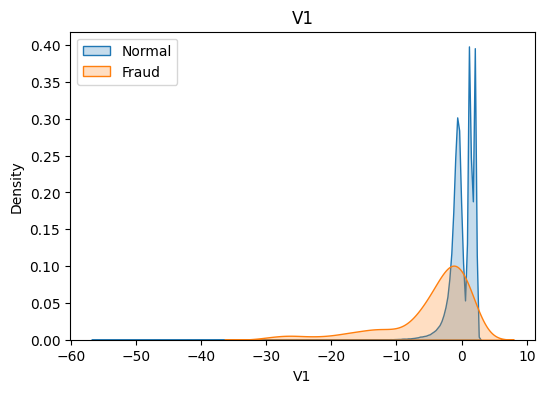

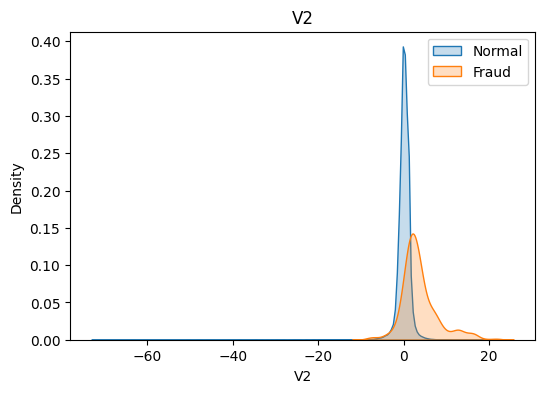

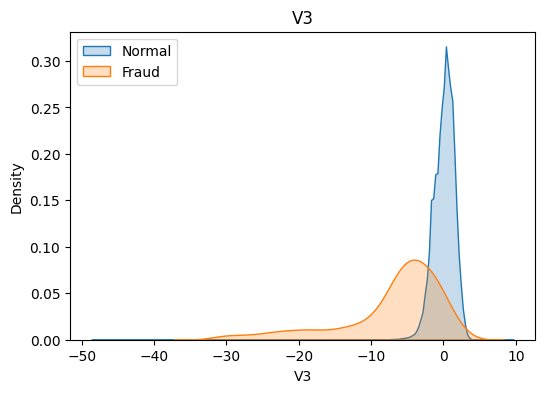

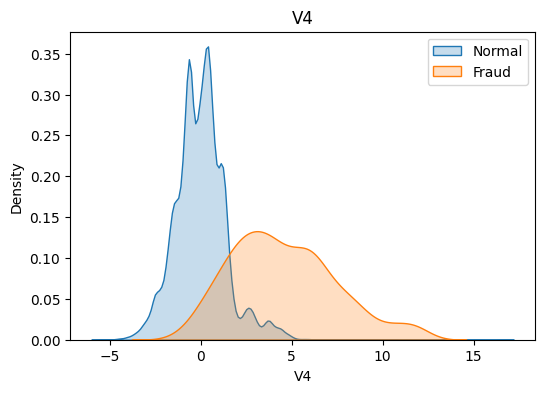

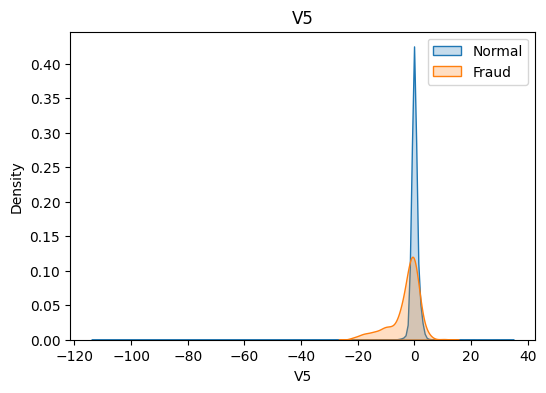

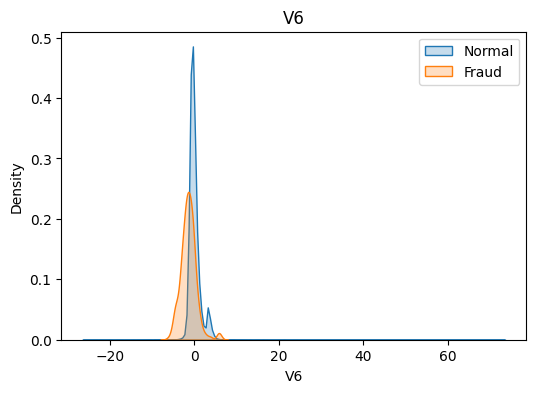

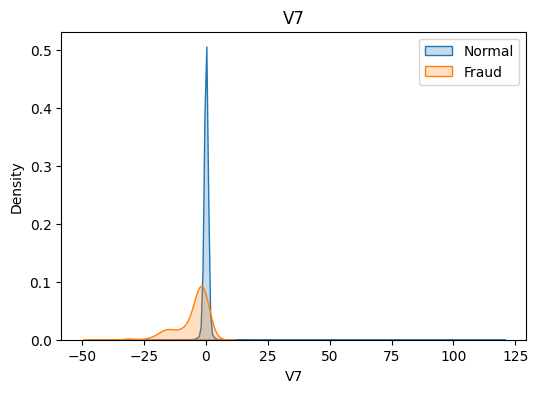

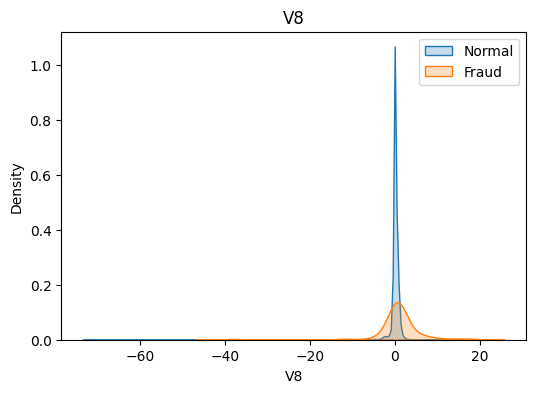

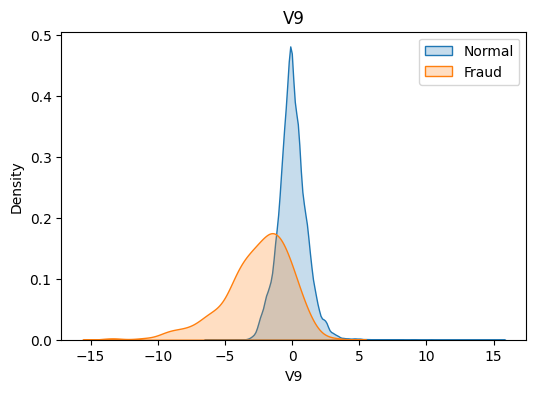

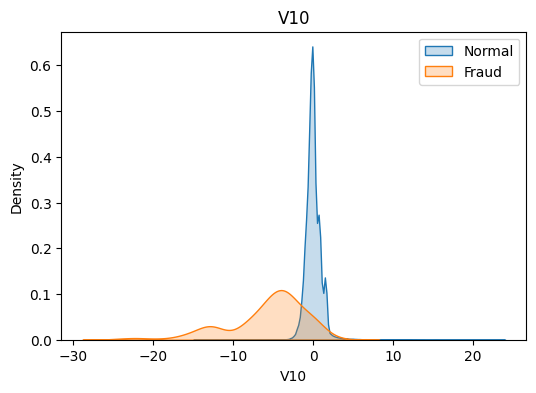

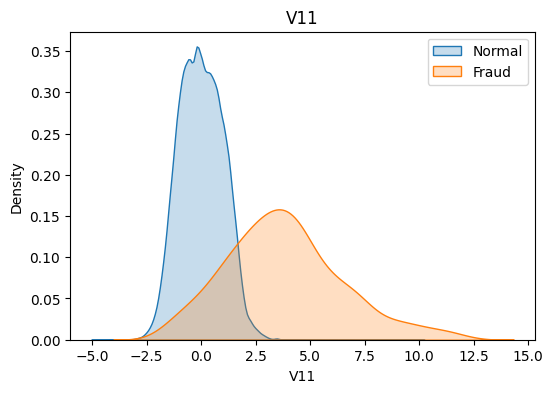

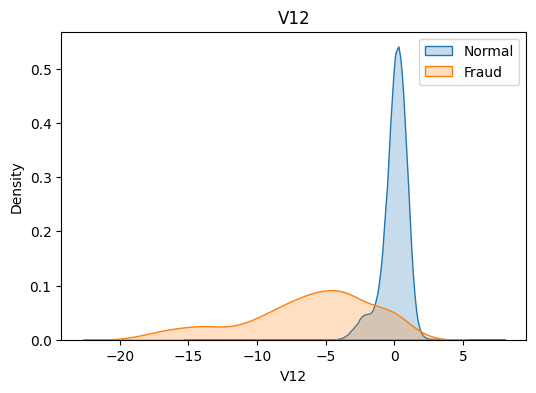

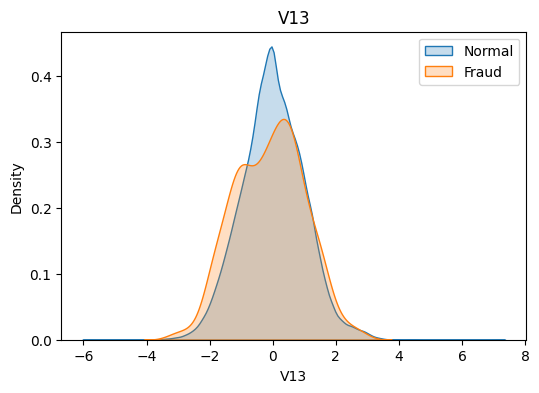

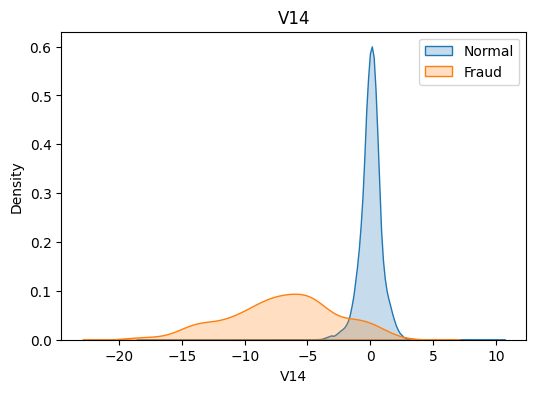

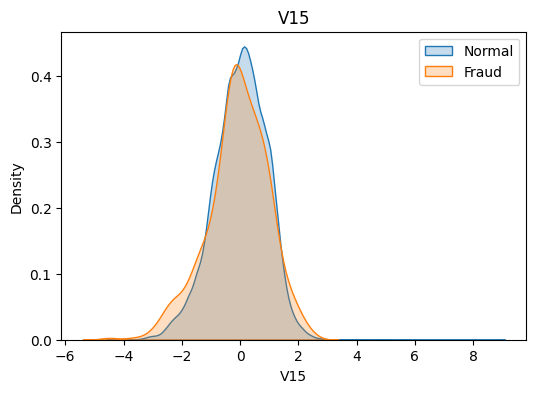

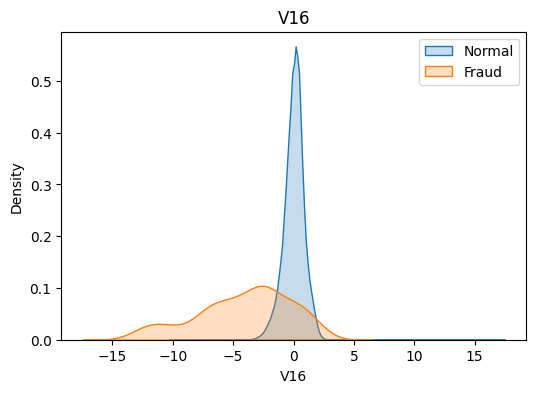

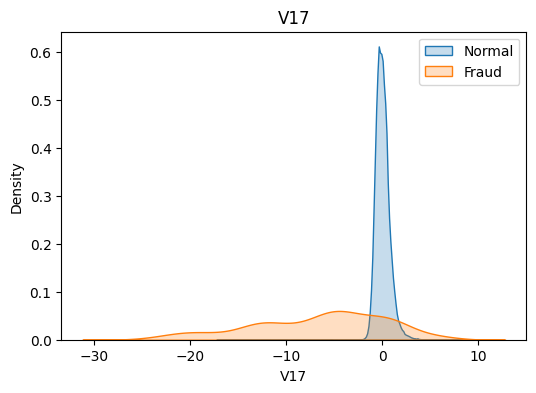

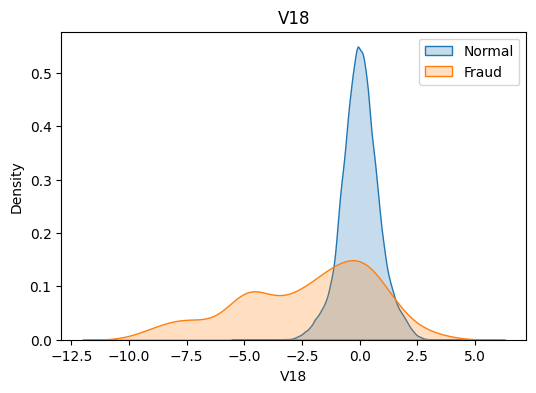

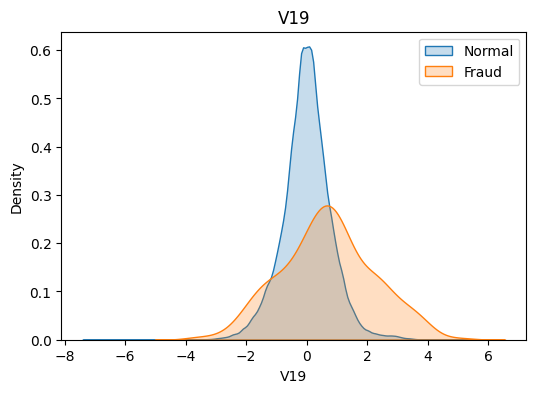

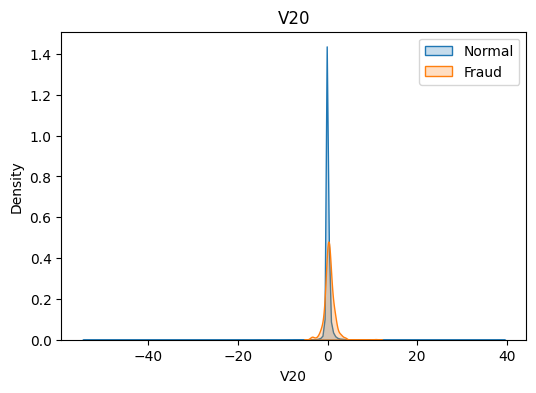

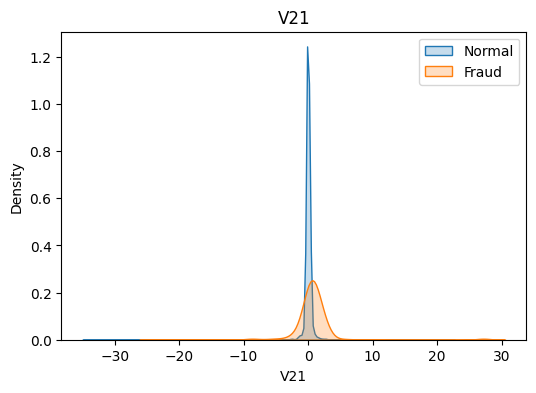

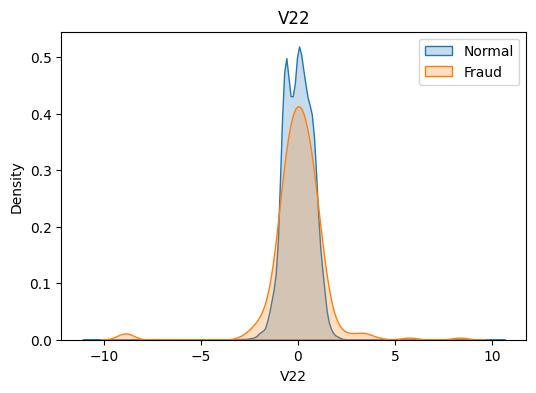

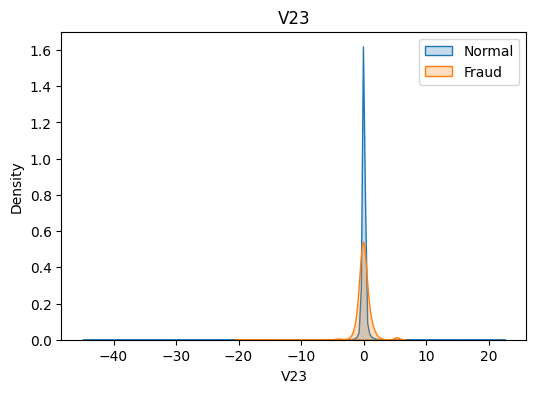

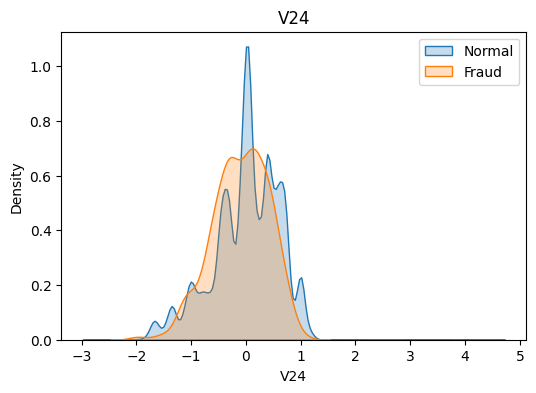

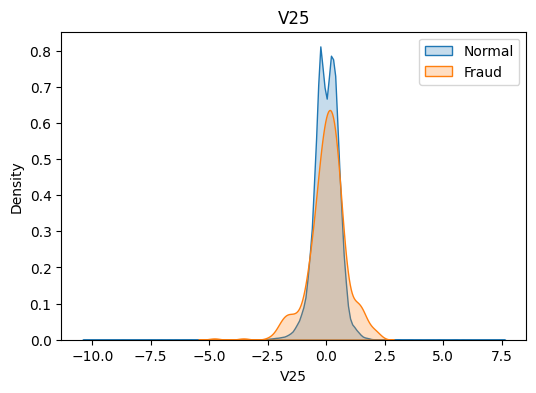

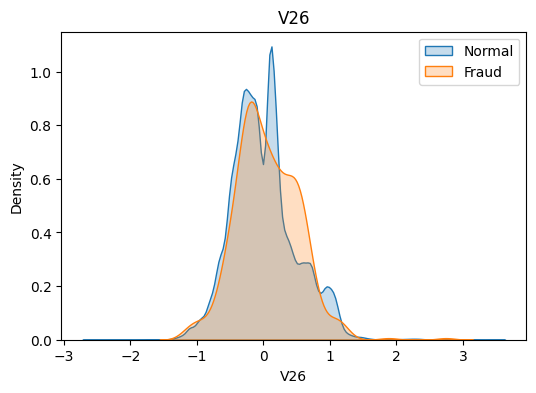

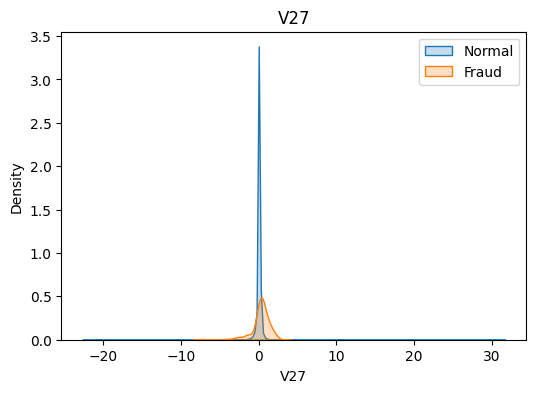

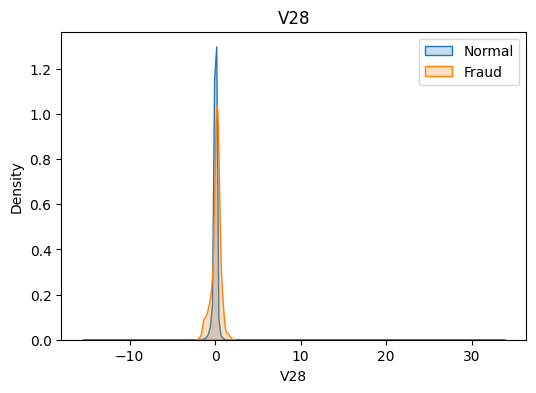

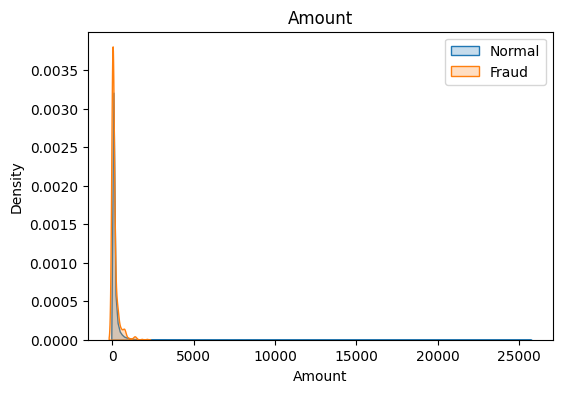

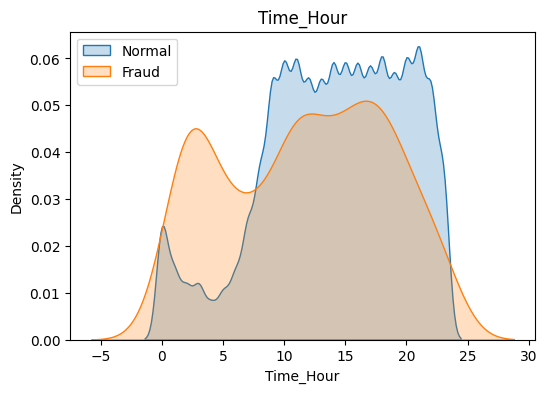

In [21]:
normal_records = df['Class'] == 0
fraud_records = df['Class'] == 1

for col in cols:
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(X[col][normal_records], label="Normal", fill=True)
    sns.kdeplot(X[col][fraud_records], label="Fraud", fill=True)
    
    plt.title(col)
    plt.legend()
    plt.show()

## Model Building

In [22]:
# Create a dataframe to store results
df_Results = pd.DataFrame(columns=['Methodology', 'Model', 'Accuracy', 'roc_value', 'threshold'])

In [23]:
# Created a common function to plot confusion matrix
def Plot_confusion_matrix(y_test, pred_test):

    cm = confusion_matrix(y_test, pred_test)

    plt.clf()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Accent)

    categoryNames = ['Non-Fraudulent', 'Fraudulent']

    plt.title('Confusion Matrix - Test Data')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    ticks = np.arange(len(categoryNames))
    plt.xticks(ticks, categoryNames, rotation=45)
    plt.yticks(ticks, categoryNames)

    s = [['TN','FP'],['FN','TP']]

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(s[i][j]) + " = " + str(cm[i][j]), fontsize=12)

    plt.show()

In [24]:
# Created a common function to fit and predict on a Logistic Regression model for both L1 and L2
def buildAndRunLogisticModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Logistic Regression
    from sklearn import linear_model
    from sklearn.model_selection import KFold

    num_C = list(np.power(10.0, np.arange(-10, 10)))

    cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

    # L2 Regularization
    searchCV_l2 = linear_model.LogisticRegressionCV(
        Cs=num_C,
        penalty='l2',
        scoring='roc_auc',
        cv=cv_num,
        random_state=42,
        max_iter=10000,
        fit_intercept=True,
        solver='newton-cg',
        tol=10
    )

    # L1 Regularization
    searchCV_l1 = linear_model.LogisticRegressionCV(
        Cs=num_C,
        penalty='l1',
        scoring='roc_auc',
        cv=cv_num,
        random_state=42,
        max_iter=10000,
        fit_intercept=True,
        solver='liblinear',
        tol=10
    )

    searchCV_l1.fit(X_train, y_train)
    searchCV_l2.fit(X_train, y_train)

    print("Max auc_roc for l1:", searchCV_l1.scores_[1].mean(axis=0).max())
    print("Max auc_roc for l2:", searchCV_l2.scores_[1].mean(axis=0).max())

    print("Parameters for l1 regularisations")
    print(searchCV_l1.coef_)
    print(searchCV_l1.intercept_)

    print("Parameters for l2 regularisations")
    print(searchCV_l2.coef_)
    print(searchCV_l2.intercept_)

    # Predictions
    y_pred_l1 = searchCV_l1.predict(X_test)
    y_pred_l2 = searchCV_l2.predict(X_test)

    # Prediction probabilities
    y_pred_probs_l1 = searchCV_l1.predict_proba(X_test)[:,1]
    y_pred_probs_l2 = searchCV_l2.predict_proba(X_test)[:,1]

    # Accuracy
    Accuracy_l2 = metrics.accuracy_score(y_test, y_pred_l2)
    Accuracy_l1 = metrics.accuracy_score(y_test, y_pred_l1)

    print("Accuracy of Logistic model with l2 regularisation:", Accuracy_l2)
    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred_l2)
    print(classification_report(y_test, y_pred_l2))

    print("Accuracy of Logistic model with l1 regularisation:", Accuracy_l1)
    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred_l1)
    print(classification_report(y_test, y_pred_l1))

    # ROC for L2
    l2_roc_value = roc_auc_score(y_test, y_pred_probs_l2)
    print("l2 roc_value:", l2_roc_value)

    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_probs_l2)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("l2 threshold:", threshold)

    roc_auc = metrics.auc(fpr, tpr)
    print("ROC for test dataset:", roc_auc)

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Store results
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'Logistic Regression with L2 Regularisation',
        'Accuracy': Accuracy_l2,
        'roc_value': l2_roc_value,
        'threshold': threshold
    }, index=[0]))

    # ROC for L1
    l1_roc_value = roc_auc_score(y_test, y_pred_probs_l1)
    print("l1 roc_value:", l1_roc_value)

    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_probs_l1)
    threshold = thresholds[np.argmax(tpr - fpr)]
    print("l1 threshold:", threshold)

    roc_auc = metrics.auc(fpr, tpr)

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'Logistic Regression with L1 Regularisation',
        'Accuracy': Accuracy_l1,
        'roc_value': l1_roc_value,
        'threshold': threshold
    }, index=[0]))

    return df_Results

In [25]:
# Created a common function to fit and predict on a KNN model
def buildAndRunKNNModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Create KNN model and fit the model with train dataset
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=16)
    knn.fit(X_train, y_train)

    score = knn.score(X_test, y_test)
    print("Model score")
    print(score)

    # Accuracy
    y_pred = knn.predict(X_test)

    KNN_Accuracy = metrics.accuracy_score(y_pred=y_pred, y_true=y_test)

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred)

    print("Classification Report")
    print(classification_report(y_test, y_pred))

    # Prediction probabilities
    knn_probs = knn.predict_proba(X_test)[:, 1]

    # Calculate ROC AUC
    knn_roc_value = roc_auc_score(y_test, knn_probs)
    print("KNN roc_value: {}".format(knn_roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, knn_probs)

    threshold = thresholds[np.argmax(tpr - fpr)]
    print("KNN threshold: {}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)

    print("ROC for the test dataset: {:.1%}".format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Store results
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'KNN',
        'Accuracy': score,
        'roc_value': knn_roc_value,
        'threshold': threshold
    }, index=[0]))

    return df_Results

In [26]:
# Created a common function to fit and predict on Tree models for both gini and entropy criteria
def buildAndRunTreeModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Evaluate Decision Tree model with 'gini' & 'entropy'
    criteria = ['gini', 'entropy']
    scores = {}

    for c in criteria:

        dt = DecisionTreeClassifier(criterion=c, random_state=42)

        dt.fit(X_train, y_train)

        y_pred = dt.predict(X_test)

        test_score = dt.score(X_test, y_test)

        tree_preds = dt.predict_proba(X_test)[:,1]

        tree_roc_value = roc_auc_score(y_test, tree_preds)

        scores[c] = test_score

        print(c + " score: {}".format(test_score))

        print("Confusion Matrix")
        Plot_confusion_matrix(y_test, y_pred)

        print("Classification Report")
        print(classification_report(y_test, y_pred))

        print(c + " tree_roc_value: {}".format(tree_roc_value))

        fpr, tpr, thresholds = metrics.roc_curve(y_test, tree_preds)

        threshold = thresholds[np.argmax(tpr - fpr)]

        print("Tree threshold: {}".format(threshold))

        roc_auc = metrics.auc(fpr, tpr)

        print("ROC for the test dataset: {:.1%}".format(roc_auc))

        plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
        plt.legend(loc=4)
        plt.show()

        # Store results
        df_Results = df_Results.append(pd.DataFrame({
            'Methodology': Methodology,
            'Model': "Tree Model with {} criteria".format(c),
            'Accuracy': test_score,
            'roc_value': tree_roc_value,
            'threshold': threshold
        }, index=[0]))

    return df_Results

In [27]:
# Created a common function to fit and predict on a Random Forest model
def buildAndRunRandomForestModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Evaluate Random Forest model

    # Create the model with 100 trees
    RF_model = RandomForestClassifier(
        n_estimators=100,
        bootstrap=True,
        max_features='sqrt',
        random_state=42
    )

    # Fit on training data
    RF_model.fit(X_train, y_train)

    RF_test_score = RF_model.score(X_test, y_test)

    RF_model.predict(X_test)

    print("Model Accuracy: {}".format(RF_test_score))

    # Actual class predictions
    rf_predictions = RF_model.predict(X_test)

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, rf_predictions)

    print("Classification Report")
    print(classification_report(y_test, rf_predictions))

    # Probabilities for each class
    rf_probs = RF_model.predict_proba(X_test)[:, 1]

    # Calculate ROC AUC
    roc_value = roc_auc_score(y_test, rf_probs)

    print("Random Forest roc_value: {}".format(roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, rf_probs)

    threshold = thresholds[np.argmax(tpr - fpr)]

    print("Random Forest threshold: {}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)

    print("ROC for the test dataset: {:.1%}".format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Store results
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'Random Forest',
        'Accuracy': RF_test_score,
        'roc_value': roc_value,
        'threshold': threshold
    }, index=[0]))

    return df_Results

In [28]:
# Created a common function to fit and predict on a XGBoost model
def buildAndRunXGBoostModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Evaluate XGBoost model
    XGBmodel = XGBClassifier(random_state=42)

    # Train model
    XGBmodel.fit(X_train, y_train)

    # Predictions
    y_pred = XGBmodel.predict(X_test)

    XGB_test_score = XGBmodel.score(X_test, y_test)

    print("Model Accuracy: {}".format(XGB_test_score))

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred)

    print("Classification Report")
    print(classification_report(y_test, y_pred))

    # Probabilities for each class
    XGB_probs = XGBmodel.predict_proba(X_test)[:, 1]

    # Calculate ROC AUC
    XGB_roc_value = roc_auc_score(y_test, XGB_probs)

    print("XGBoost roc_value: {}".format(XGB_roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, XGB_probs)

    threshold = thresholds[np.argmax(tpr - fpr)]

    print("XGBoost threshold: {}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)

    print("ROC for the test dataset: {:.1%}".format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc=" + str(roc_auc))
    plt.legend(loc=4)
    plt.show()

    # Store results
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'XGBoost',
        'Accuracy': XGB_test_score,
        'roc_value': XGB_roc_value,
        'threshold': threshold
    }, index=[0]))

    return df_Results

In [29]:
# Created a common function to fit and predict on a SVM model
def buildAndRunSVMModels(df_Results, Methodology, X_train, y_train, X_test, y_test):

    # Evaluate SVM model with sigmoid kernel
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score, roc_auc_score

    clf = SVC(kernel='sigmoid', random_state=42)

    clf.fit(X_train, y_train)

    y_pred_SVM = clf.predict(X_test)

    SVM_Score = accuracy_score(y_test, y_pred_SVM)

    print("accuracy_score : {}".format(SVM_Score))

    print("Confusion Matrix")
    Plot_confusion_matrix(y_test, y_pred_SVM)

    print("classification Report")
    print(classification_report(y_test, y_pred_SVM))

    # Run classifier with probability enabled
    classifier = SVC(kernel='sigmoid', probability=True)

    svm_probs = classifier.fit(X_train, y_train).predict_proba(X_test)[:,1]

    # Calculate ROC AUC
    roc_value = roc_auc_score(y_test, svm_probs)

    print("SVM roc_value : {}".format(roc_value))

    fpr, tpr, thresholds = metrics.roc_curve(y_test, svm_probs)

    threshold = thresholds[np.argmax(tpr - fpr)]

    print("SVM threshold : {}".format(threshold))

    roc_auc = metrics.auc(fpr, tpr)

    print("ROC for the test dataset : {:.1%}".format(roc_auc))

    plt.plot(fpr, tpr, label="Test, auc="+str(roc_auc))

    plt.legend(loc=4)

    plt.show()

    # Store results
    df_Results = df_Results.append(pd.DataFrame({
        'Methodology': Methodology,
        'Model': 'SVM',
        'Accuracy': SVM_Score,
        'roc_value': roc_value,
        'threshold': threshold
    }, index=[0]))

    return df_Results

## Perform cross validation with RepeatedKFold

In [30]:
# Lets perform RepeatedKFold and check the results
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=None)

# X is the feature set and y is the target
for train_index, test_index in rkf.split(X, y):
    
    print("TRAIN:", train_index, "TEST:", test_index)

    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

TRAIN: [     2      3      4 ... 284801 284802 284805] TEST: [     0      1      9 ... 284803 284804 284806]
TRAIN: [     0      1      3 ... 284803 284804 284806] TEST: [     2      4      5 ... 284795 284801 284805]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     3     13     14 ... 284762 284786 284787]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     8     15     22 ... 284785 284788 284790]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     6     16     28 ... 284799 284800 284802]
TRAIN: [     0      3      4 ... 284802 284803 284804] TEST: [     1      2      5 ... 284797 284805 284806]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [     3     15     17 ... 284768 284795 284800]
TRAIN: [     1      2      3 ... 284804 284805 284806] TEST: [     0     11     22 ... 284788 284790 284803]
TRAIN: [     0      1      2 ... 284803 284805 284806] TEST: [     4      7      9 ... 284798 284799 284804]
TRAIN: [     0     

In [31]:
import time

In [32]:
pd.DataFrame.append = lambda self, other: pd.concat([self, other], ignore_index=True)

Logistic Regression with L1 And L2 Regularisation
Max auc_roc for l1: 0.975759413047046
Max auc_roc for l2: 0.570959603791529
Parameters for l1 regularisations
[[-0.06090089 -0.13875355 -0.18386091  0.0711904  -0.26926438  0.09643061
   0.11912672 -0.03717687 -0.14464669 -0.1510416  -0.02456234  0.00048166
  -0.13776039 -0.23209801  0.01304838 -0.12021965 -0.23739347  0.02779601
   0.0080764   0.23585322  0.09695667 -0.03185107 -0.04568713 -0.01648325
  -0.04023113  0.00200461 -0.05626022  0.02979617 -0.00671666 -0.11612835]]
[-2.08720979]
Parameters for l2 regularisations
[[-1.48697544e-07  7.47509887e-08 -1.81394445e-07  1.23176191e-07
  -9.22781710e-08 -1.93389786e-08 -1.41863588e-07  2.19473945e-08
  -6.23401952e-08 -1.49812808e-07  1.12233934e-07 -1.67963085e-07
   1.27234496e-09 -1.77309376e-07 -6.10578960e-09 -1.05406104e-07
  -1.75836500e-07 -6.59669241e-08  1.69870333e-08  3.85250118e-09
   2.24898488e-08 -3.94130611e-09 -6.95950381e-09 -3.52638201e-09
   3.23301960e-09  4.951

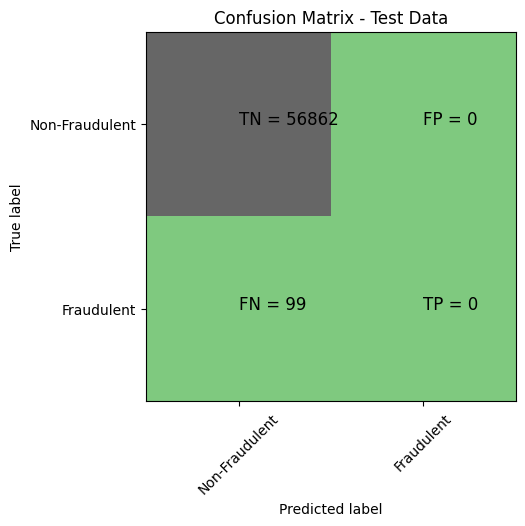

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.00      0.00      0.00        99

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

Accuracy of Logistic model with l1 regularisation: 0.9991046505503766
Confusion Matrix


C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

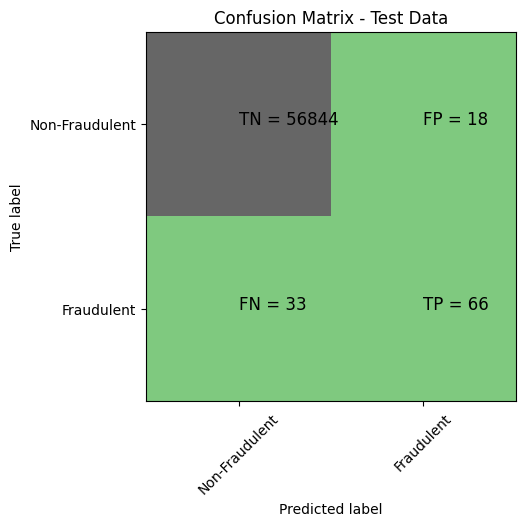

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.79      0.67      0.72        99

    accuracy                           1.00     56961
   macro avg       0.89      0.83      0.86     56961
weighted avg       1.00      1.00      1.00     56961

l2 roc_value: 0.5318620057989056
l2 threshold: 0.4992566255328345
ROC for test dataset: 0.5318620057989056


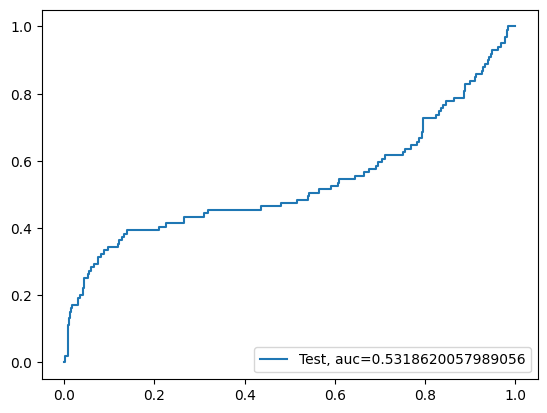

C:\Users\Saksham Kaushik\AppData\Local\Temp\ipykernel_29076\769438208.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.DataFrame.append = lambda self, other: pd.concat([self, other], ignore_index=True)


l1 roc_value: 0.8825629230293153
l1 threshold: 0.1067044579727915


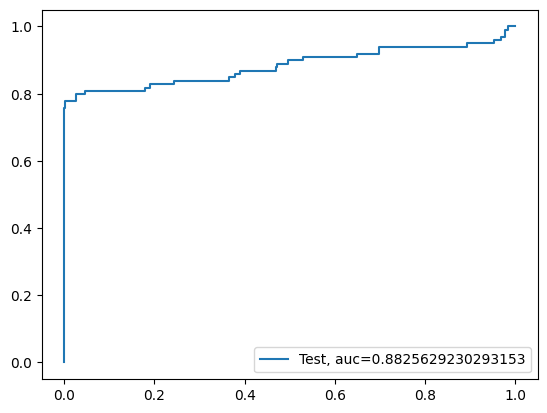

Time Taken: 119.29331040382385
------------------------------------------------------------
KNN Model
Model score
0.999280209265989
Confusion Matrix


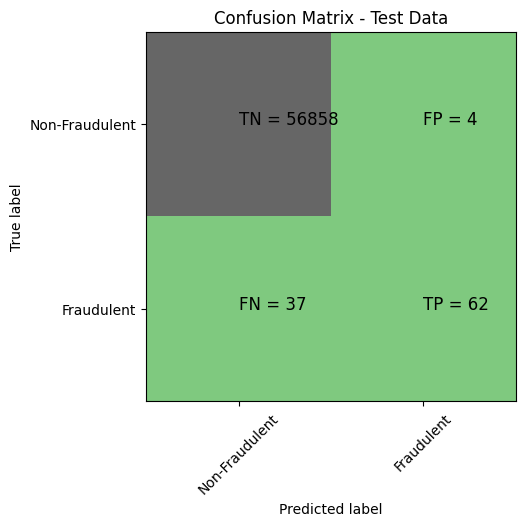

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.94      0.63      0.75        99

    accuracy                           1.00     56961
   macro avg       0.97      0.81      0.88     56961
weighted avg       1.00      1.00      1.00     56961

KNN roc_value: 0.8887252817293969
KNN threshold: 0.2
ROC for the test dataset: 88.9%


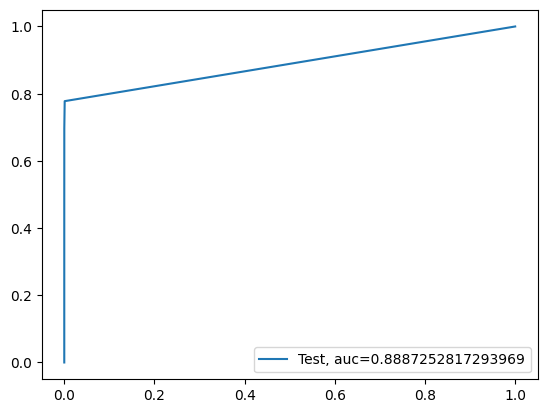

Time Taken: 64.29183101654053
------------------------------------------------------------


In [33]:
# Logistic Regression
print("Logistic Regression with L1 And L2 Regularisation")

start_time = time.time()

df_Results = buildAndRunLogisticModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)

print("Time Taken:", time.time() - start_time)
print('-'*60)


# KNN Model
print("KNN Model")

start_time = time.time()

df_Results = buildAndRunKNNModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)

print("Time Taken:", time.time() - start_time)
print('-'*60)

Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.9990870946788153
Confusion Matrix


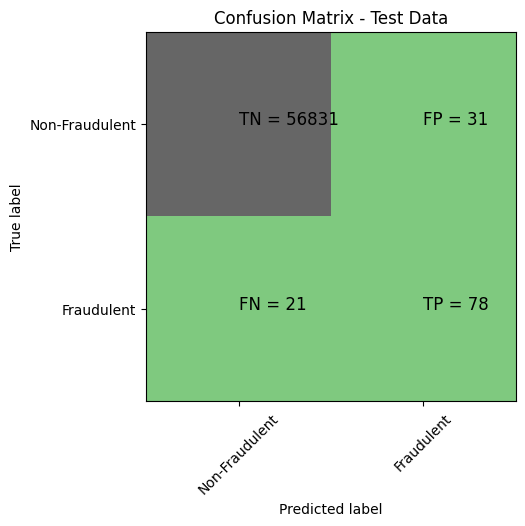

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.72      0.79      0.75        99

    accuracy                           1.00     56961
   macro avg       0.86      0.89      0.87     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8936668041606313
Tree threshold: 1.0
ROC for the test dataset: 89.4%


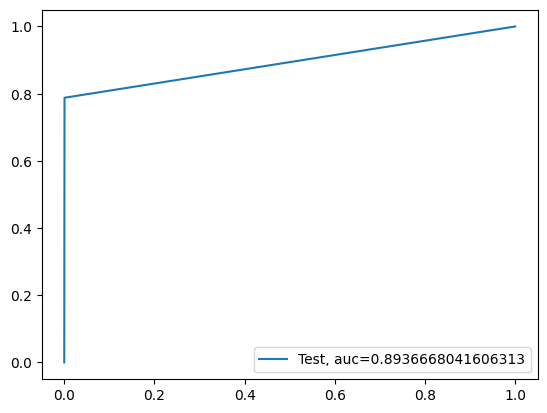

entropy score: 0.9990344270641316
Confusion Matrix


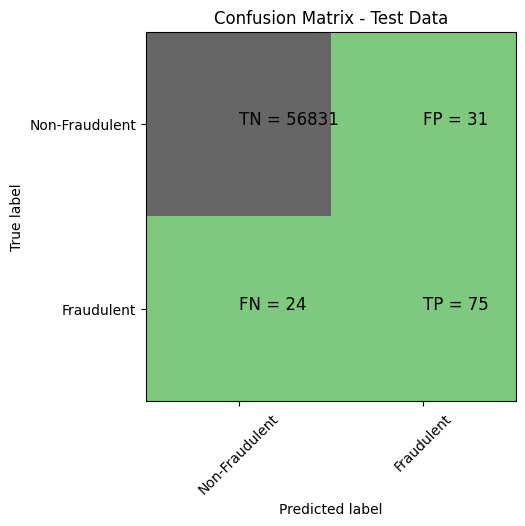

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.71      0.76      0.73        99

    accuracy                           1.00     56961
   macro avg       0.85      0.88      0.87     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8785152890091162
Tree threshold: 1.0
ROC for the test dataset: 87.9%


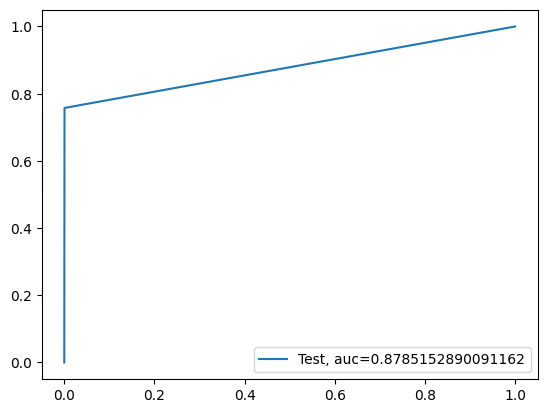

Time Taken: 65.0335099697113
------------------------------------------------------------


In [34]:
print("Decision Tree Models with 'gini' & 'entropy' criteria")

start_time = time.time()

df_Results = buildAndRunTreeModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)

print("Time Taken:", time.time() - start_time)
print('-'*60)

Random Forest Model
Model Accuracy: 0.999490879724724
Confusion Matrix


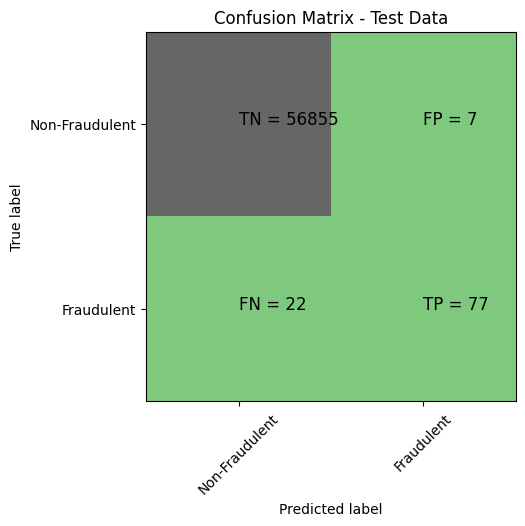

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.92      0.78      0.84        99

    accuracy                           1.00     56961
   macro avg       0.96      0.89      0.92     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest roc_value: 0.9375605977114895
Random Forest threshold: 0.01
ROC for the test dataset: 93.8%


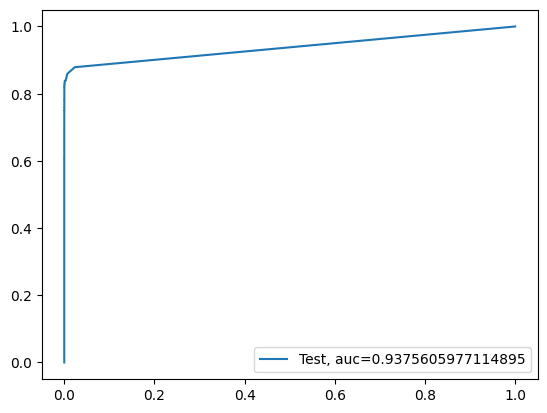

Time Taken: 482.3472111225128
------------------------------------------------------------
XGBoost Model
Model Accuracy: 0.9994557679816014
Confusion Matrix


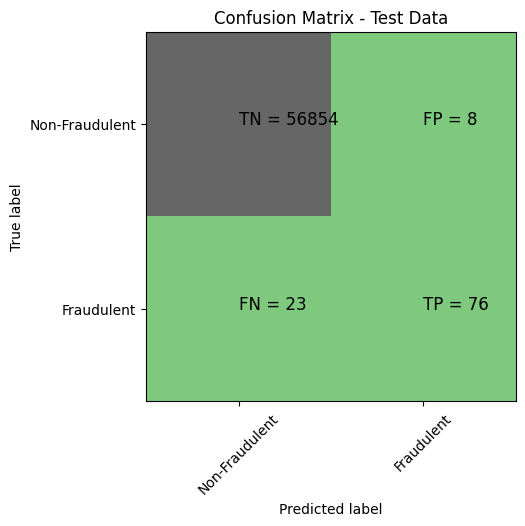

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56862
           1       0.90      0.77      0.83        99

    accuracy                           1.00     56961
   macro avg       0.95      0.88      0.92     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost roc_value: 0.9523022067603687
XGBoost threshold: 0.00010421610932098702
ROC for the test dataset: 95.2%


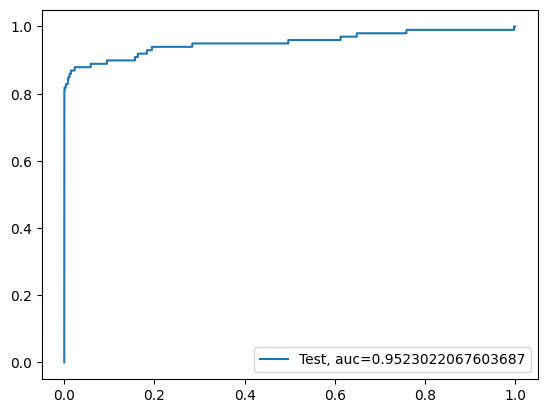

Time Taken: 5.857286691665649
------------------------------------------------------------


In [35]:
# Random Forest
print("Random Forest Model")

start_time = time.time()

df_Results = buildAndRunRandomForestModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)

print("Time Taken:", time.time() - start_time)
print('-'*60)


# XGBoost
print("XGBoost Model")

start_time = time.time()

df_Results = buildAndRunXGBoostModels(
    df_Results,
    "RepeatedKFold Cross Validation",
    X_train_cv, y_train_cv,
    X_test_cv, y_test_cv
)

print("Time Taken:", time.time() - start_time)
print('-'*60)

In [36]:
df_Results

,Methodology,Model,Accuracy,roc_value,threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998262,0.531862,0.499257
1,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999105,0.882563,0.106704
2,RepeatedKFold Cross Validation,KNN,0.999280,0.888725,0.200000
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999087,0.893667,1.000000
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999034,0.878515,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999491,0.937561,0.010000
6,RepeatedKFold Cross Validation,XGBoost,0.999456,0.952302,0.000104


## Perform StratifiedKFold and check the results

In [37]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=None)

# X is the feature set and y is the target
for train_index, test_index in skf.split(X, y):
    
    print("TRAIN:", train_index, "TEST:", test_index)
    
    X_train_SKF_cv, X_test_SKF_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_SKF_cv, y_test_SKF_cv = y.iloc[train_index], y.iloc[test_index]

TRAIN: [ 30473  30496  31002 ... 284804 284805 284806] TEST: [    0     1     2 ... 57017 57018 57019]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [ 30473  30496  31002 ... 113964 113965 113966]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [ 81609  82400  83053 ... 170946 170947 170948]
TRAIN: [     0      1      2 ... 284804 284805 284806] TEST: [150654 150660 150661 ... 227866 227867 227868]
TRAIN: [     0      1      2 ... 227866 227867 227868] TEST: [212516 212644 213092 ... 284804 284805 284806]


Logistic Regression with L1 And L2 Regularisation
Max auc_roc for l1: 0.9652106893977332
Max auc_roc for l2: 0.5597020083683936
Parameters for l1 regularisations
[[-0.03660539 -0.1358827  -0.20474594  0.04333662 -0.24034598  0.08416903
   0.12654905 -0.04815306 -0.14258132 -0.1384162  -0.11668372  0.05505155
  -0.15637116 -0.24216184 -0.03137093 -0.09904364 -0.23133976  0.05582481
   0.02122044  0.20503748  0.09013502  0.00148754 -0.03796378 -0.00392139
  -0.14797782 -0.00701001 -0.06594801 -0.00660368 -0.00656465 -0.12981985]]
[-2.0409044]
Parameters for l2 regularisations
[[ 3.59840980e-07  2.10530060e-07 -1.58002317e-06 -2.04884044e-07
   3.76472678e-07 -2.67633109e-07  3.13241030e-08 -1.20226136e-08
  -8.98863463e-08 -1.54002314e-07 -4.65334035e-07  1.57441535e-07
  -1.27094538e-07 -4.38050832e-07 -3.73274685e-07 -8.23337714e-08
  -3.16607926e-07  1.01807717e-07  7.54814354e-08 -6.47175864e-08
   7.04219521e-08  1.73013268e-07  7.32726162e-08 -1.03599764e-08
  -2.85545640e-07 -2.03

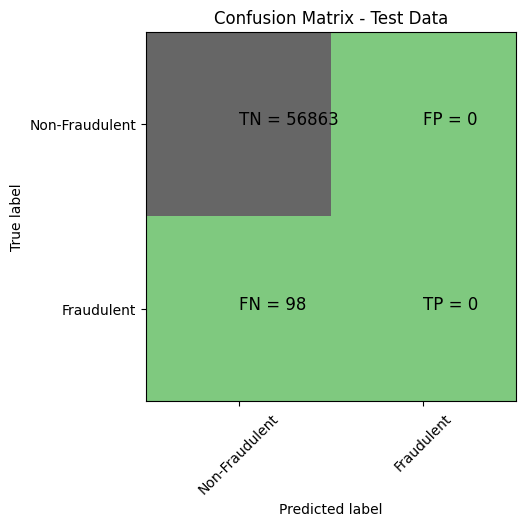

C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

Accuracy of Logistic model with l1 regularisation: 0.9987535331191517
Confusion Matrix


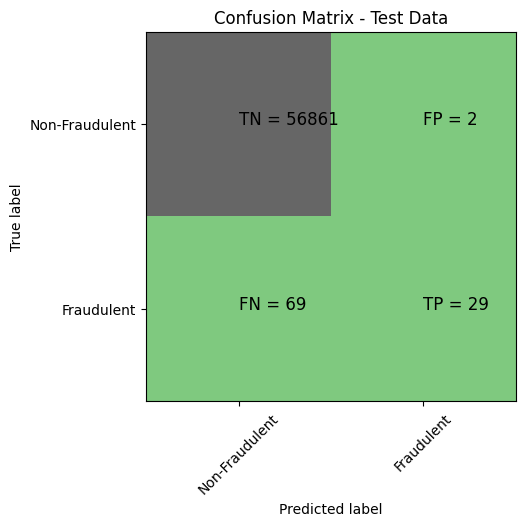

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.94      0.30      0.45        98

    accuracy                           1.00     56961
   macro avg       0.97      0.65      0.72     56961
weighted avg       1.00      1.00      1.00     56961

l2 roc_value: 0.6111619154810686
l2 threshold: 0.4993921957728673
ROC for test dataset: 0.6111619154810686


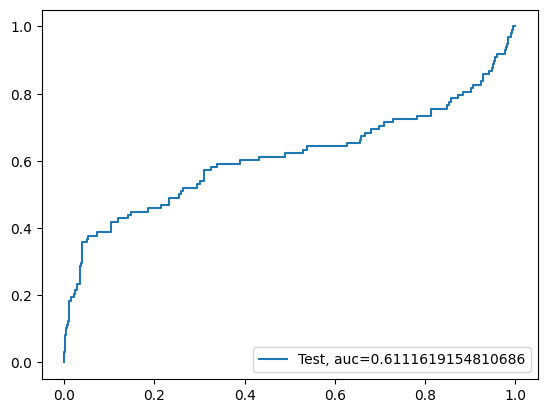

l1 roc_value: 0.8890758561483437
l1 threshold: 0.021087492766199856


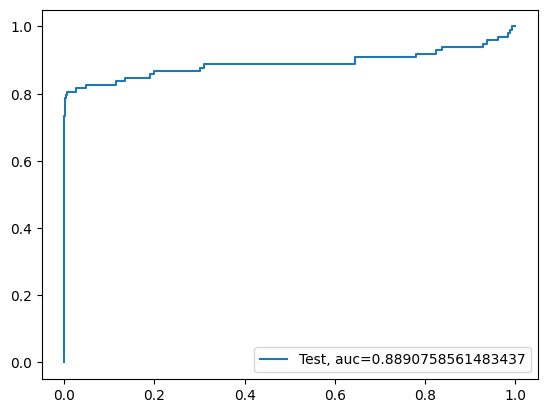

Time Taken by Model: --- 227.47989082336426 seconds ---
------------------------------------------------------------


In [38]:
# Run Logistic Regression with L1 And L2 Regularisation
print("Logistic Regression with L1 And L2 Regularisation")

start_time = time.time()

df_Results = buildAndRunLogisticModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv, y_train_SKF_cv,
    X_test_SKF_cv, y_test_SKF_cv
)

print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

KNN Model
Model score
0.9991924299081828
Confusion Matrix


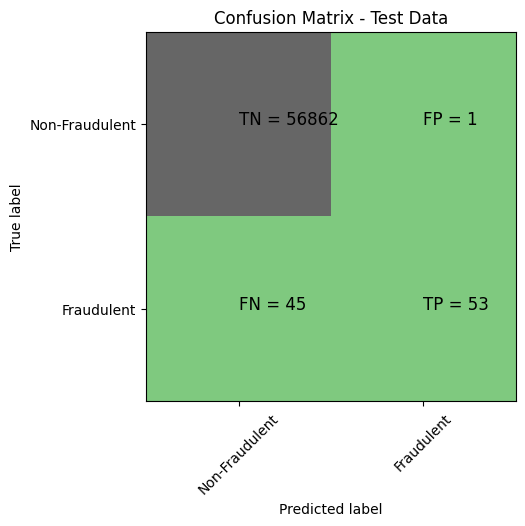

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.98      0.54      0.70        98

    accuracy                           1.00     56961
   macro avg       0.99      0.77      0.85     56961
weighted avg       1.00      1.00      1.00     56961

KNN roc_value: 0.8057457828285457
KNN threshold: 0.2
ROC for the test dataset: 80.6%


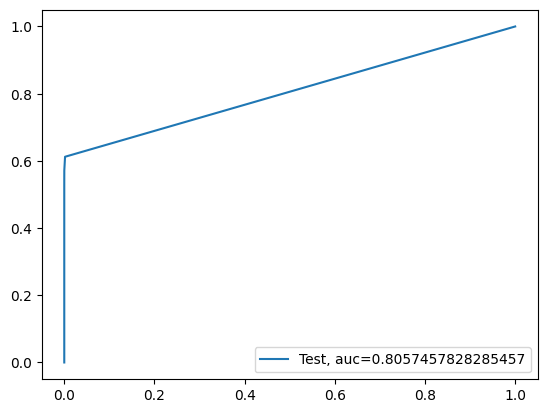

Time Taken by Model: --- 153.23728036880493 seconds ---
------------------------------------------------------------


In [39]:
## Run KNN Model
print("KNN Model")

start_time = time.time()

df_Results = buildAndRunKNNModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv, y_train_SKF_cv,
    X_test_SKF_cv, y_test_SKF_cv
)

print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

Decision Tree Models with 'gini' & 'entropy' criteria
gini score: 0.998841312476958
Confusion Matrix


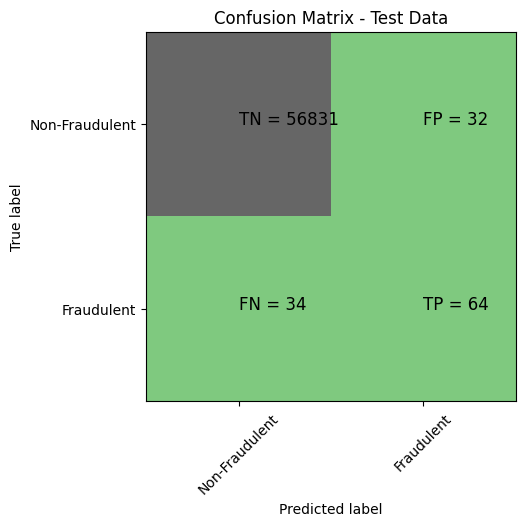

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.67      0.65      0.66        98

    accuracy                           1.00     56961
   macro avg       0.83      0.83      0.83     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8262492341959029
Tree threshold: 1.0
ROC for the test dataset: 82.6%


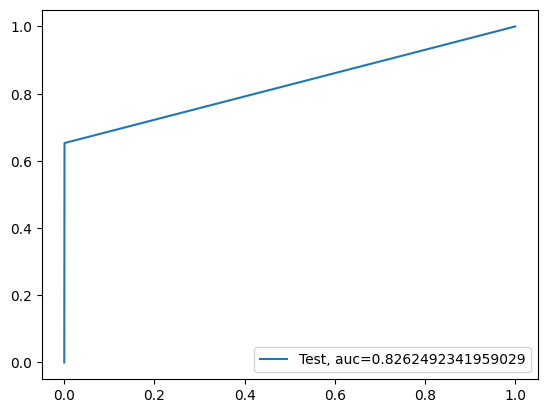

entropy score: 0.9990168711925703
Confusion Matrix


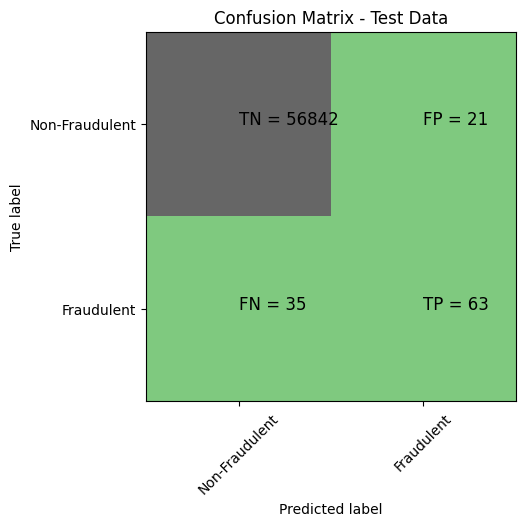

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.75      0.64      0.69        98

    accuracy                           1.00     56961
   macro avg       0.87      0.82      0.85     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8212439170839185
Tree threshold: 1.0
ROC for the test dataset: 82.1%


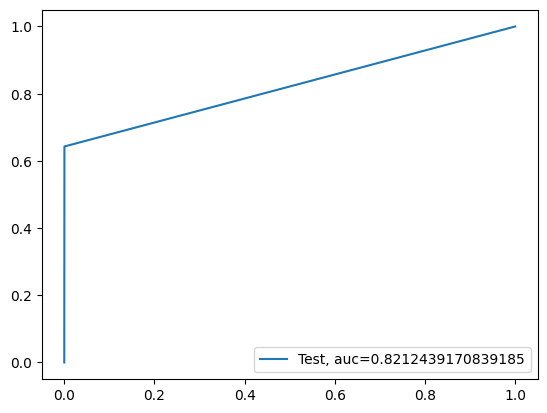

Time Taken by Model: --- 101.56304550170898 seconds ---
------------------------------------------------------------


In [40]:
# Decision Tree Models with 'gini' & 'entropy' criteria
print("Decision Tree Models with 'gini' & 'entropy' criteria")

start_time = time.time()

df_Results = buildAndRunTreeModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv, y_train_SKF_cv,
    X_test_SKF_cv, y_test_SKF_cv
)

print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

Random Forest Model
Model Accuracy: 0.9994382121100402
Confusion Matrix


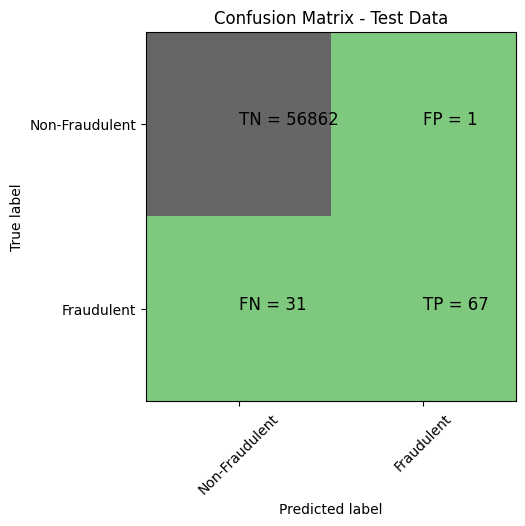

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.99      0.68      0.81        98

    accuracy                           1.00     56961
   macro avg       0.99      0.84      0.90     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest roc_value: 0.9464721329855826
Random Forest threshold: 0.01
ROC for the test dataset: 94.6%


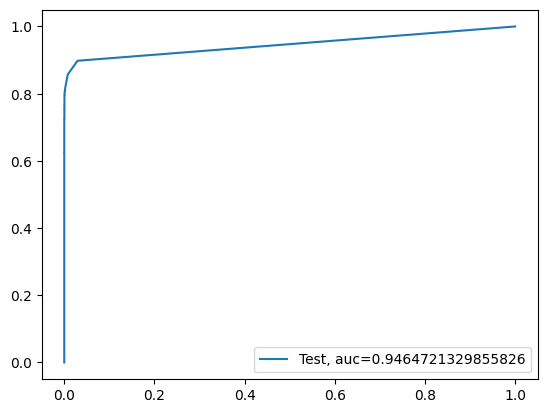

Time Taken by Model: --- 658.1866140365601 seconds ---
------------------------------------------------------------


In [41]:
# Run Random Forest Model
print("Random Forest Model")

start_time = time.time()

df_Results = buildAndRunRandomForestModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv, y_train_SKF_cv,
    X_test_SKF_cv, y_test_SKF_cv
)

print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

XGBoost Model
Model Accuracy: 0.9991748740366215
Confusion Matrix


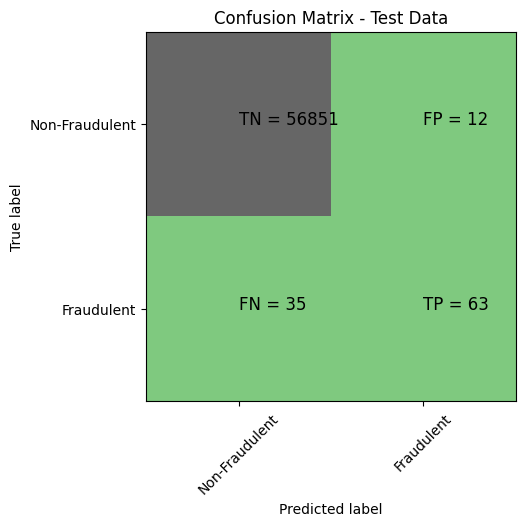

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.84      0.64      0.73        98

    accuracy                           1.00     56961
   macro avg       0.92      0.82      0.86     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost roc_value: 0.9192701613293964
XGBoost threshold: 7.963625103002414e-05
ROC for the test dataset: 91.9%


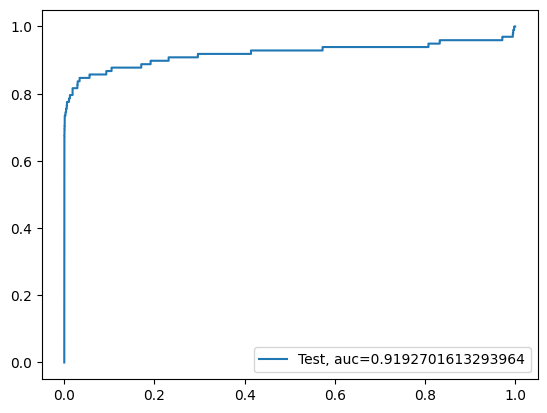

Time Taken by Model: --- 5.701665163040161 seconds ---
------------------------------------------------------------


In [42]:
#  XGBoost Model
print("XGBoost Model")

start_time = time.time()

df_Results = buildAndRunXGBoostModels(
    df_Results,
    "StratifiedKFold Cross Validation",
    X_train_SKF_cv, y_train_SKF_cv,
    X_test_SKF_cv, y_test_SKF_cv
)

print("Time Taken by Model: --- %s seconds ---" % (time.time() - start_time))
print('-'*60)

In [43]:
df_Results

,Methodology,Model,Accuracy,roc_value,threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998262,0.531862,0.499257
1,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999105,0.882563,0.106704
2,RepeatedKFold Cross Validation,KNN,0.999280,0.888725,0.200000
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999087,0.893667,1.000000
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999034,0.878515,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999491,0.937561,0.010000
6,RepeatedKFold Cross Validation,XGBoost,0.999456,0.952302,0.000104
7,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998280,0.611162,0.499392
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.998754,0.889076,0.021087
9,StratifiedKFold Cross Validation,KNN,0.999192,0.805746,0.200000


## Results for Cross Validation with StratifiedKFold

Looking at the ROC value, **Logistic Regression with L2 Regularisation** has provided the best results for cross validation using the **StratifiedKFold technique**.


In [44]:
# Logistic Regression
from sklearn import linear_model
from sklearn.model_selection import KFold

num_C = list(np.power(10.0, np.arange(-10, 10)))

cv_num = KFold(n_splits=10, shuffle=True, random_state=42)

clf = linear_model.LogisticRegressionCV(
    Cs=num_C,
    penalty='l2',
    scoring='roc_auc',
    cv=cv_num,
    random_state=42,
    max_iter=10000,
    fit_intercept=True,
    solver='newton-cg',
    tol=10
)

clf.fit(X_train_SKF_cv, y_train_SKF_cv)

print('Max auc_roc for l2:', clf.scores_[1].mean(axis=0).max())

print("Parameters for l2 regularisations")
print(clf.coef_)
print(clf.intercept_)
print(clf.scores_)

# Find predicted values
y_pred_l2 = clf.predict(X_test)

# Find predicted probabilities
y_pred_probs_l2 = clf.predict_proba(X_test)[:, 1]

# Accuracy of l2 model
Accuracy_l2 = metrics.accuracy_score(y_pred=y_pred_l2, y_true=y_test)

print("Accuracy of Logistic model with l2 regularisation : {0}".format(Accuracy_l2))

from sklearn.metrics import roc_auc_score

l2_roc_value = roc_auc_score(y_test, y_pred_probs_l2)
print("l2 roc_value: {0}".format(l2_roc_value))

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_probs_l2)

threshold = thresholds[np.argmax(tpr - fpr)]

print("l2 threshold: {0}".format(threshold))

Max auc_roc for l2: 0.5597020083683936
Parameters for l2 regularisations
[[ 3.59840980e-07  2.10530060e-07 -1.58002317e-06 -2.04884044e-07
   3.76472678e-07 -2.67633109e-07  3.13241030e-08 -1.20226136e-08
  -8.98863463e-08 -1.54002314e-07 -4.65334035e-07  1.57441535e-07
  -1.27094538e-07 -4.38050832e-07 -3.73274685e-07 -8.23337714e-08
  -3.16607926e-07  1.01807717e-07  7.54814354e-08 -6.47175864e-08
   7.04219521e-08  1.73013268e-07  7.32726162e-08 -1.03599764e-08
  -2.85545640e-07 -2.03747293e-08  3.38203553e-09 -1.32510707e-08
  -6.82254904e-04 -9.57433590e-05]]
[-7.52178855e-06]
{np.int64(1): array([[0.48266925, 0.48178322, 0.47951852, 0.47631818, 0.47631818,
        0.47631818, 0.47631818, 0.47631818, 0.47631818, 0.47631818,
        0.47631818, 0.47631818, 0.47631818, 0.47631818, 0.47631818,
        0.47631818, 0.47631818, 0.47631818, 0.47631818, 0.47631818],
       [0.55602862, 0.55598183, 0.55533056, 0.55524448, 0.55524448,
        0.55524448, 0.55524448, 0.55524448, 0.55524448, 

In [45]:
clf.coef_

array([[ 3.59840980e-07,  2.10530060e-07, -1.58002317e-06,
        -2.04884044e-07,  3.76472678e-07, -2.67633109e-07,
         3.13241030e-08, -1.20226136e-08, -8.98863463e-08,
        -1.54002314e-07, -4.65334035e-07,  1.57441535e-07,
        -1.27094538e-07, -4.38050832e-07, -3.73274685e-07,
        -8.23337714e-08, -3.16607926e-07,  1.01807717e-07,
         7.54814354e-08, -6.47175864e-08,  7.04219521e-08,
         1.73013268e-07,  7.32726162e-08, -1.03599764e-08,
        -2.85545640e-07, -2.03747293e-08,  3.38203553e-09,
        -1.32510707e-08, -6.82254904e-04, -9.57433590e-05]])

In [46]:
# Creating a dataframe with the coefficient values
coefficients = pd.concat(
    [pd.DataFrame(X.columns), pd.DataFrame(np.transpose(clf.coef_))],
    axis=1
)

coefficients.columns = ['Feature', 'Importance Coefficient']

coefficients

,Feature,Importance Coefficient
0,V1,3.598410e-07
1,V2,2.105301e-07
2,V3,-1.580023e-06
3,V4,-2.048840e-07
4,V5,3.764727e-07
5,V6,-2.676331e-07
6,V7,3.132410e-08
7,V8,-1.202261e-08
8,V9,-8.988635e-08
9,V10,-1.540023e-07


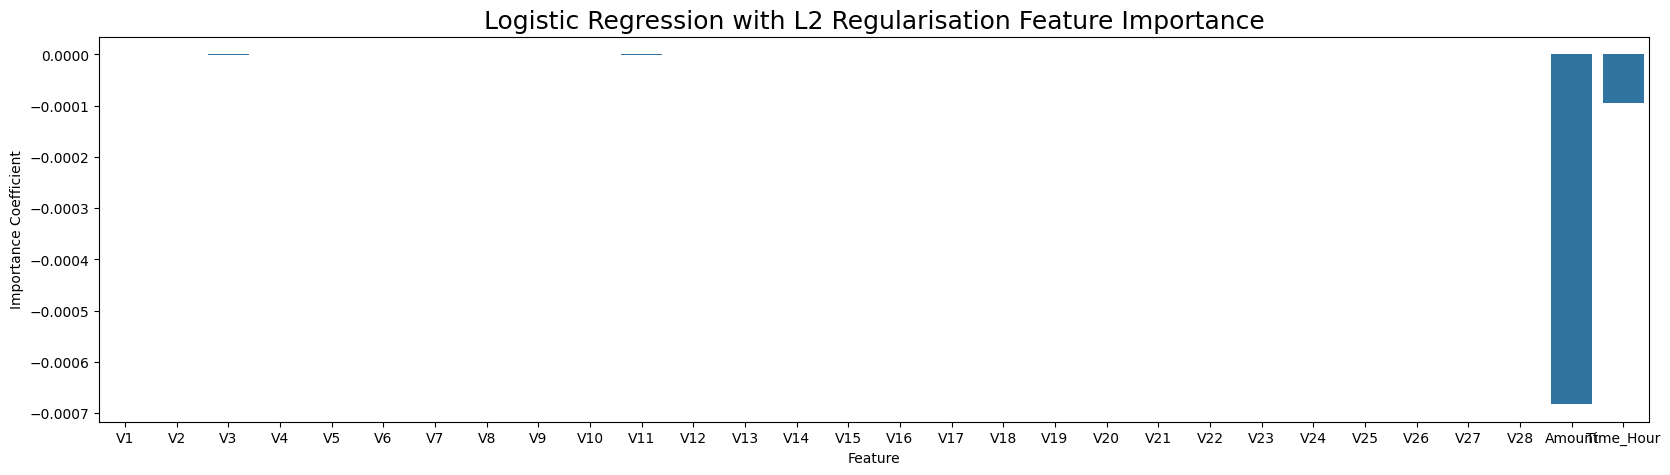

In [47]:
# Plotting the coefficient values
plt.figure(figsize=(20,5))

sns.barplot(
    x='Feature',
    y='Importance Coefficient',
    data=coefficients
)

plt.title(
    "Logistic Regression with L2 Regularisation Feature Importance",
    fontsize=18
)

plt.show()

In [48]:
# Creating dataframe with SMOTE and StratifiedKFold

from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):

    X_train = X.loc[train_index]
    y_train = y.loc[train_index]

    X_test = X.loc[test_index]
    y_test = y.loc[test_index]

    # Apply SMOTE oversampling
    SMOTE = over_sampling.SMOTE(random_state=0)

    X_train_Smote, y_train_Smote = SMOTE.fit_resample(X_train, y_train)

# Convert to dataframe
X_train_Smote = pd.DataFrame(data=X_train_Smote, columns=cols)

Logistic Regression with L1 and L2 Regularisation
Max auc_roc for l1: 0.5
Max auc_roc for l2: 0.5
Parameters for l1 regularisations
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]
[0.]
Parameters for l2 regularisations
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]
[0.]
Accuracy of Logistic model with l2 regularisation: 0.9982795245869981
Confusion Matrix


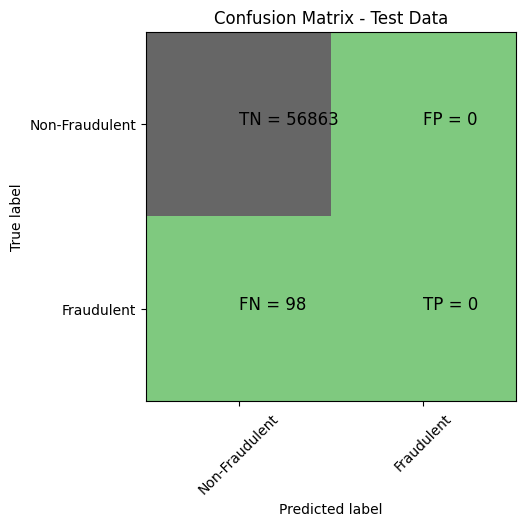

C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

Accuracy of Logistic model with l1 regularisation: 0.9982795245869981
Confusion Matrix


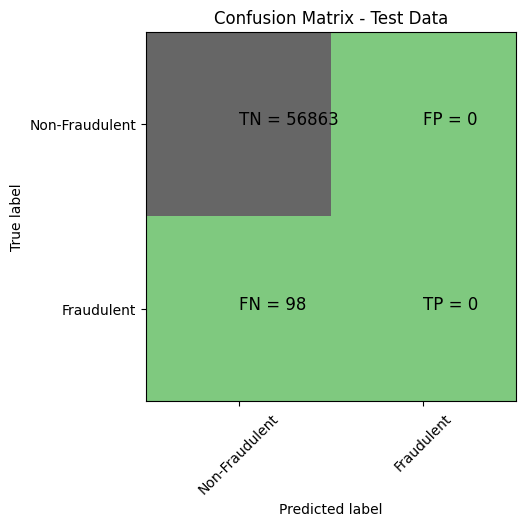

C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

l2 roc_value: 0.5
l2 threshold: inf
ROC for test dataset: 0.5


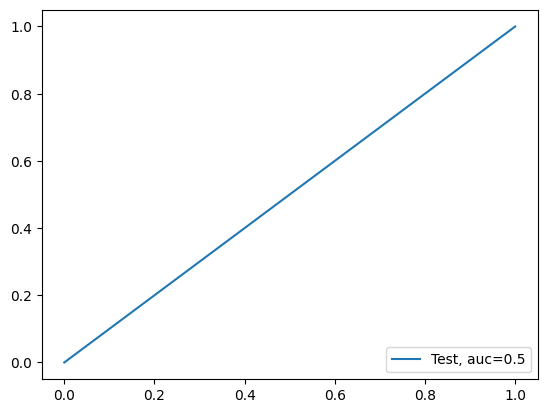

l1 roc_value: 0.5
l1 threshold: inf


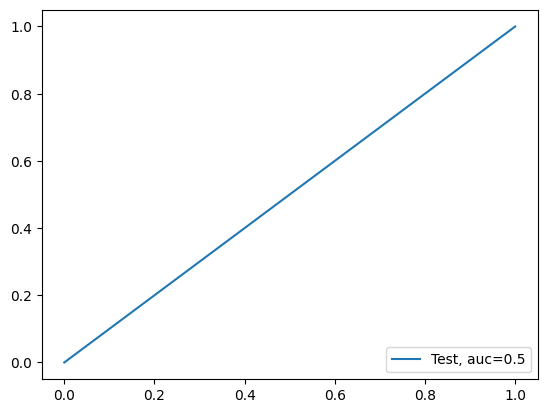

Time Taken by Model: 521.1332056522369
--------------------------------------------------------------------------------


In [49]:
Data_Imbalance_Handling = "SMOTE Oversampling with StratifiedKFold CV"

print("Logistic Regression with L1 and L2 Regularisation")

start_time = time.time()

df_Results = buildAndRunLogisticModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_Smote, y_train_Smote,
    X_test, y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

KNN Model
Model score
0.9946805709169432
Confusion Matrix


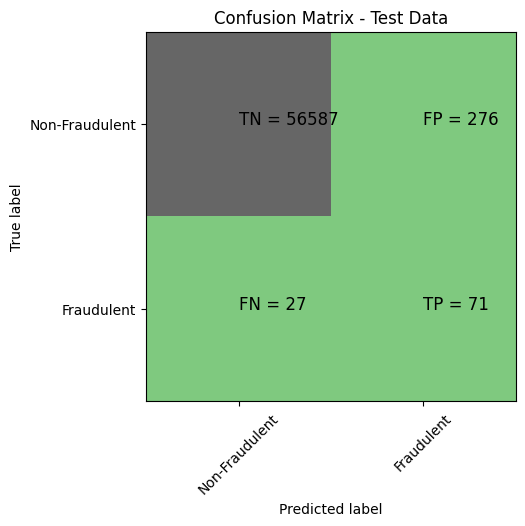

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.20      0.72      0.32        98

    accuracy                           0.99     56961
   macro avg       0.60      0.86      0.66     56961
weighted avg       1.00      0.99      1.00     56961

KNN roc_value: 0.8602674455287628
KNN threshold: 0.6
ROC for the test dataset: 86.0%


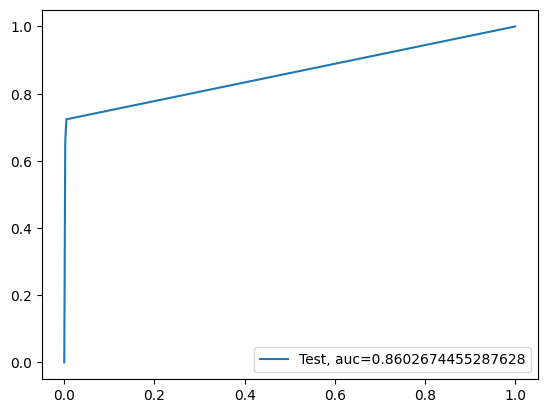

Time Taken by Model: 291.2016158103943
--------------------------------------------------------------------------------


In [50]:
print("KNN Model")

start_time = time.time()

df_Results = buildAndRunKNNModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_Smote, y_train_Smote,
    X_test, y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

Decision Tree Models with gini & entropy criteria
gini score: 0.9977001808254771
Confusion Matrix


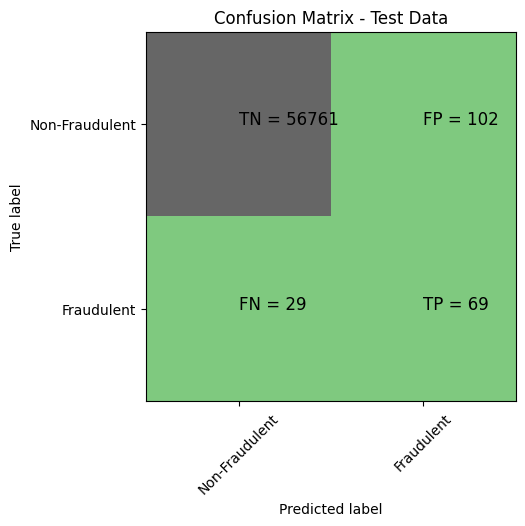

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.40      0.70      0.51        98

    accuracy                           1.00     56961
   macro avg       0.70      0.85      0.76     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8511439237953592
Tree threshold: 1.0
ROC for the test dataset: 85.1%


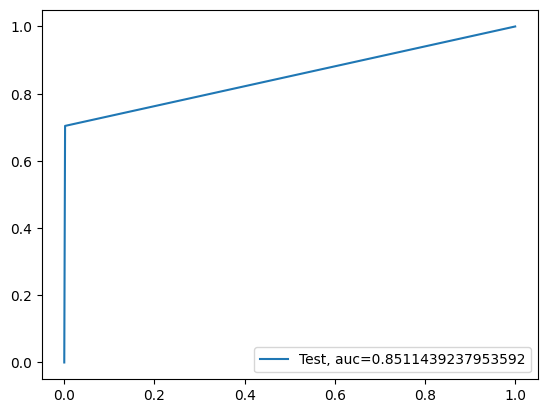

entropy score: 0.9969803900914661
Confusion Matrix


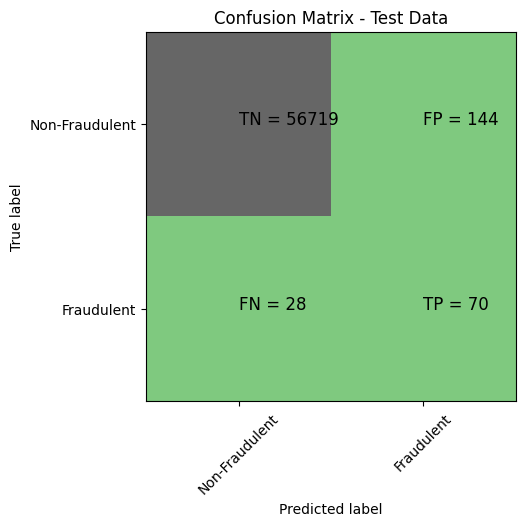

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.33      0.71      0.45        98

    accuracy                           1.00     56961
   macro avg       0.66      0.86      0.72     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8558766559223799
Tree threshold: 1.0
ROC for the test dataset: 85.6%


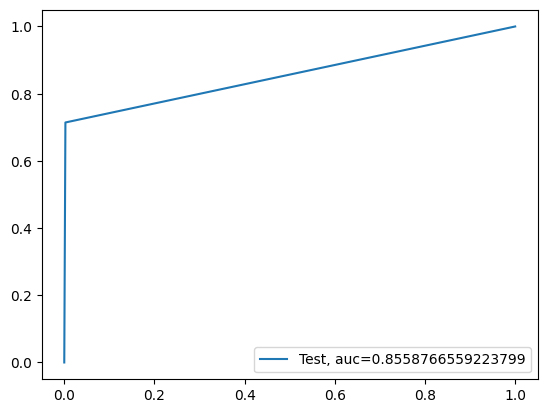

Time Taken by Model: 244.20097184181213
--------------------------------------------------------------------------------


In [51]:
print("Decision Tree Models with gini & entropy criteria")

start_time = time.time()

df_Results = buildAndRunTreeModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_Smote, y_train_Smote,
    X_test, y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

Random Forest Model
Model Accuracy: 0.999490879724724
Confusion Matrix


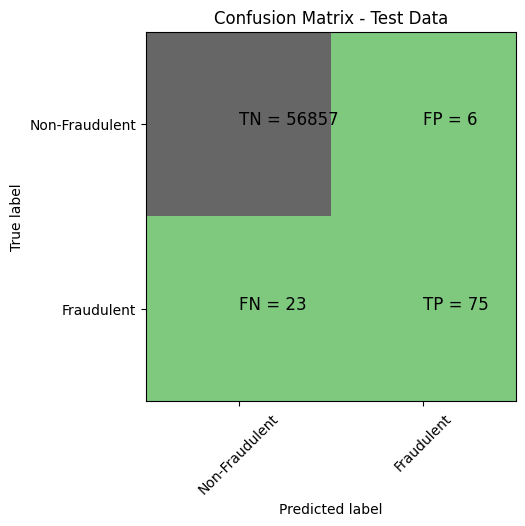

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.93      0.77      0.84        98

    accuracy                           1.00     56961
   macro avg       0.96      0.88      0.92     56961
weighted avg       1.00      1.00      1.00     56961

Random Forest roc_value: 0.9653649283078161
Random Forest threshold: 0.05
ROC for the test dataset: 96.5%


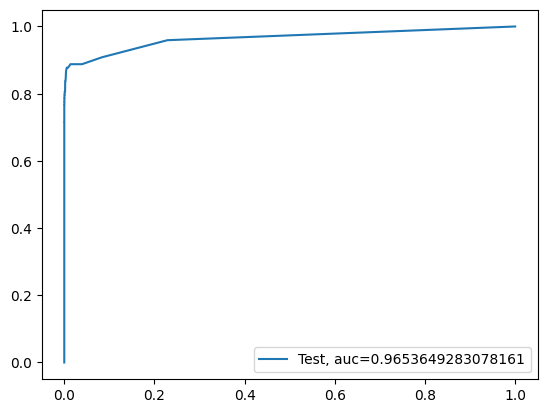

Time Taken by Model: 1155.7491238117218
--------------------------------------------------------------------------------


In [52]:
print("Random Forest Model")

start_time = time.time()

df_Results = buildAndRunRandomForestModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_Smote, y_train_Smote,
    X_test, y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

XGBoost Model
Model Accuracy: 0.9994031003669177
Confusion Matrix


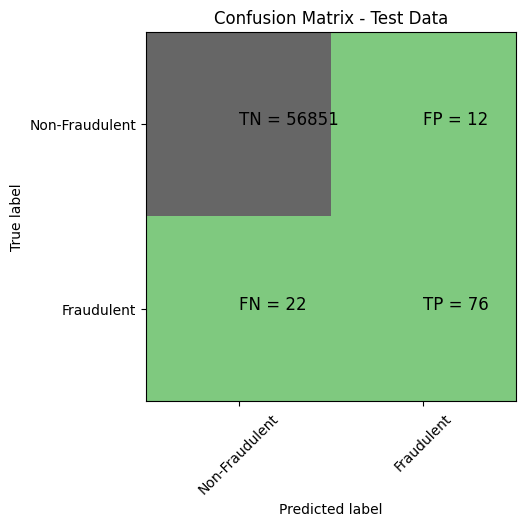

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.86      0.78      0.82        98

    accuracy                           1.00     56961
   macro avg       0.93      0.89      0.91     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost roc_value: 0.9704734293344512
XGBoost threshold: 0.000144163059303537
ROC for the test dataset: 97.0%


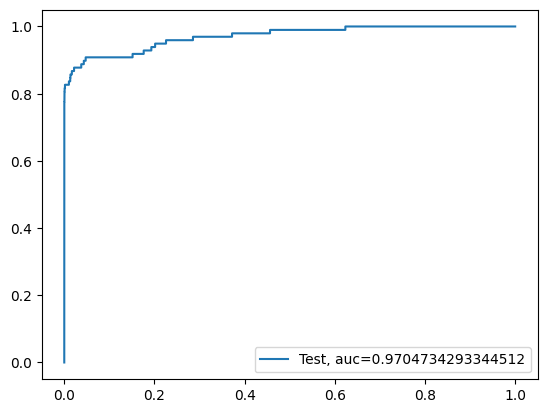

Time Taken by Model: 11.276265859603882
--------------------------------------------------------------------------------


In [53]:
print("XGBoost Model")

start_time = time.time()

df_Results = buildAndRunXGBoostModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_Smote, y_train_Smote,
    X_test, y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

In [54]:
df_Results

,Methodology,Model,Accuracy,roc_value,threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998262,0.531862,0.499257
1,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999105,0.882563,0.106704
2,RepeatedKFold Cross Validation,KNN,0.999280,0.888725,0.200000
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999087,0.893667,1.000000
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999034,0.878515,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999491,0.937561,0.010000
6,RepeatedKFold Cross Validation,XGBoost,0.999456,0.952302,0.000104
7,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998280,0.611162,0.499392
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.998754,0.889076,0.021087
9,StratifiedKFold Cross Validation,KNN,0.999192,0.805746,0.200000


## Results for SMOTE Oversampling with StratifiedKFold

Looking at the Accuracy and ROC-AUC score, we observe that **XGBoost** provides the best results when SMOTE Oversampling is applied with StratifiedKFold cross-validation.

## Oversampling with ADASYN Oversampling

In [55]:
# Creating dataframe with ADASYN and StratifiedKFold

from sklearn.model_selection import StratifiedKFold
from imblearn import over_sampling

skf = StratifiedKFold(n_splits=5, random_state=None)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):

    X_train = X.loc[train_index]
    y_train = y.loc[train_index]

    X_test = X.loc[test_index]
    y_test = y.loc[test_index]

    ADASYN = over_sampling.ADASYN(random_state=0)

    X_train_ADASYN, y_train_ADASYN = ADASYN.fit_resample(X_train, y_train)

# Convert to dataframe
X_train_ADASYN = pd.DataFrame(data=X_train_ADASYN, columns=cols)

Logistic Regression with L1 And L2 Regularisation
Max auc_roc for l1: 0.5
Max auc_roc for l2: 0.6091741619819793
Parameters for l1 regularisations
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]
[0.]
Parameters for l2 regularisations
[[-2.01595537e-05  1.72317688e-05 -3.64909067e-05  3.39290450e-05
  -1.46234036e-05 -8.46815505e-06 -2.20942850e-05  3.85352425e-07
  -1.34235180e-05 -3.75798463e-05  2.79794199e-05 -4.50836936e-05
  -2.12360047e-06 -5.56215470e-05  1.17193947e-06 -2.74594763e-05
  -4.06813002e-05 -1.20266028e-05  4.49719240e-06  1.33830143e-06
   6.32715682e-06  5.58244410e-07 -2.26605364e-06 -8.54000002e-07
  -5.65808664e-07 -2.03181861e-07  2.36428895e-06  7.75570254e-07
   1.29444742e-03 -2.92744751e-05]]
[-9.9952445e-07]
Accuracy of Logistic model with l2 regularisation: 0.011200646056073453
Confusion Matrix


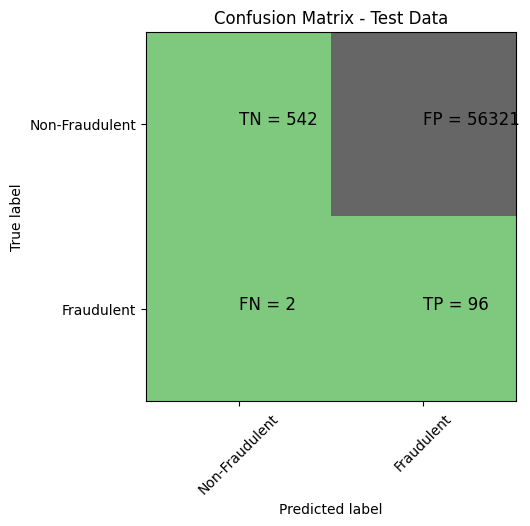

              precision    recall  f1-score   support

           0       1.00      0.01      0.02     56863
           1       0.00      0.98      0.00        98

    accuracy                           0.01     56961
   macro avg       0.50      0.49      0.01     56961
weighted avg       0.99      0.01      0.02     56961

Accuracy of Logistic model with l1 regularisation: 0.9982795245869981
Confusion Matrix


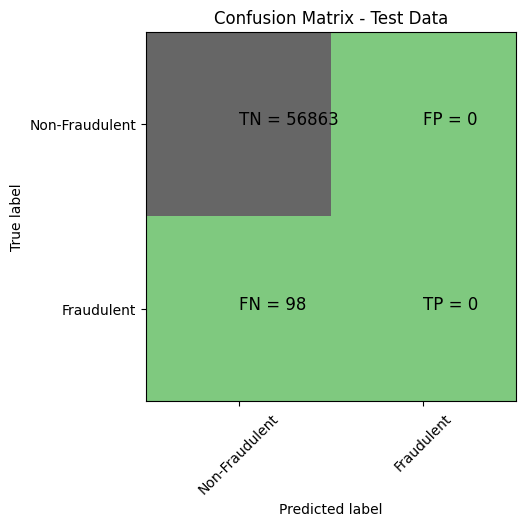

C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

l2 roc_value: 0.4511041037768184
l2 threshold: 0.5762819111863158
ROC for test dataset: 0.4511041037768184


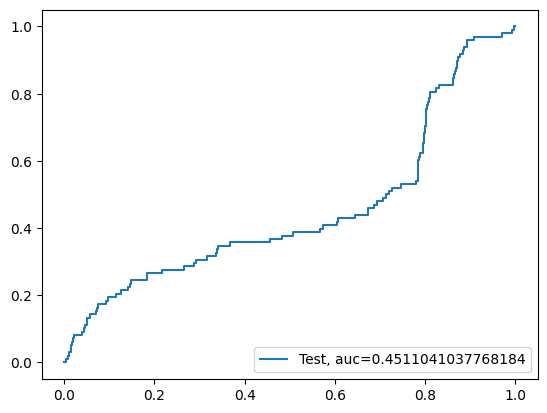

l1 roc_value: 0.5
l1 threshold: inf


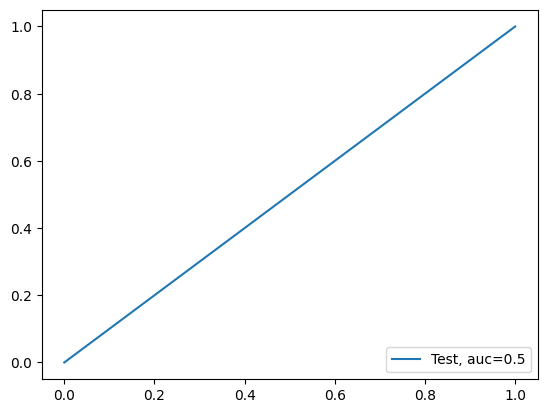

Time Taken by Model: 244.1768181324005
--------------------------------------------------------------------------------


In [56]:
Data_Imbalance_Handling = "ADASYN Oversampling with StratifiedKFold CV"
print("Logistic Regression with L1 And L2 Regularisation")

start_time = time.time()

df_Results = buildAndRunLogisticModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_ADASYN,
    y_train_ADASYN,
    X_test,
    y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

KNN Model
Model score
0.9945050122013307
Confusion Matrix


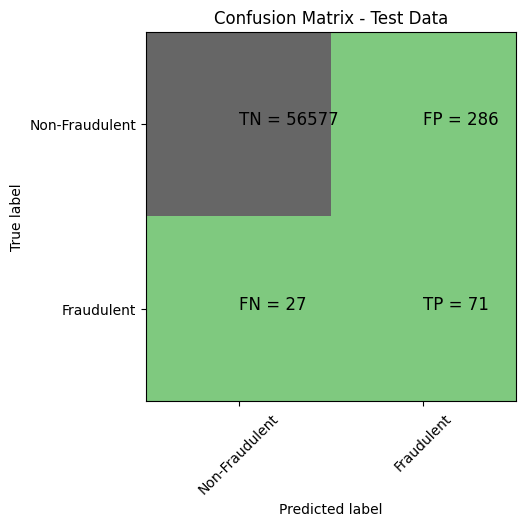

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.20      0.72      0.31        98

    accuracy                           0.99     56961
   macro avg       0.60      0.86      0.65     56961
weighted avg       1.00      0.99      1.00     56961

KNN roc_value: 0.8601937811862167
KNN threshold: 0.6
ROC for the test dataset: 86.0%


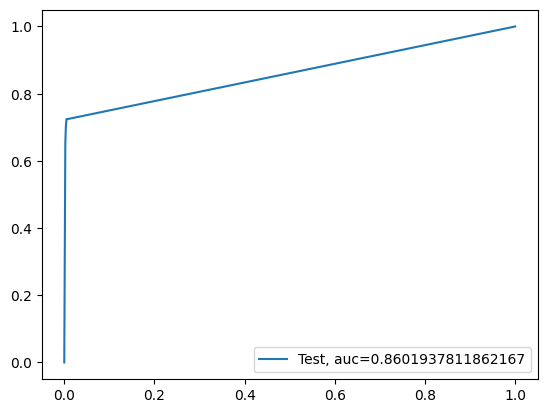

Time Taken by Model: 164.2711799144745
--------------------------------------------------------------------------------


In [57]:
print("KNN Model")

start_time = time.time()

df_Results = buildAndRunKNNModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_ADASYN,
    y_train_ADASYN,
    X_test,
    y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

Decision Tree Models with gini & entropy criteria
gini score: 0.9979459630273345
Confusion Matrix


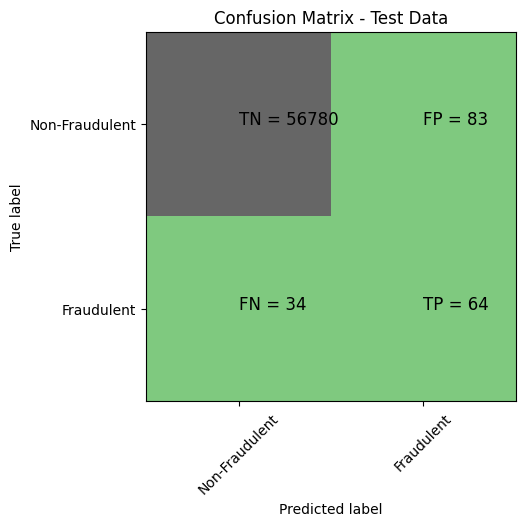

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.44      0.65      0.52        98

    accuracy                           1.00     56961
   macro avg       0.72      0.83      0.76     56961
weighted avg       1.00      1.00      1.00     56961

gini tree_roc_value: 0.8258007879303172
Tree threshold: 1.0
ROC for the test dataset: 82.6%


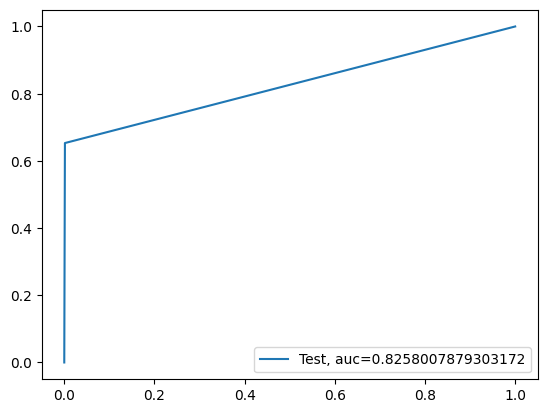

entropy score: 0.9954179175225154
Confusion Matrix


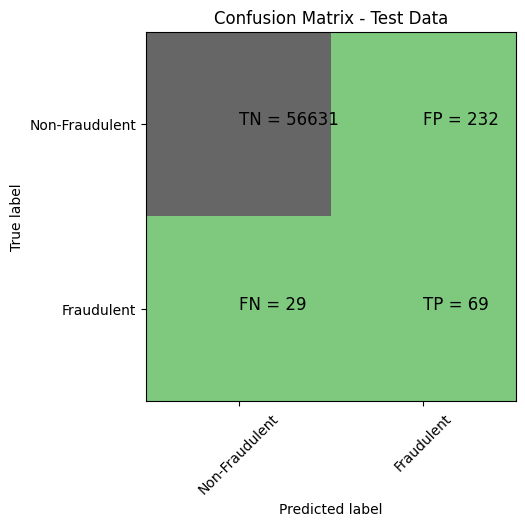

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.23      0.70      0.35        98

    accuracy                           1.00     56961
   macro avg       0.61      0.85      0.67     56961
weighted avg       1.00      1.00      1.00     56961

entropy tree_roc_value: 0.8500008254713172
Tree threshold: 1.0
ROC for the test dataset: 85.0%


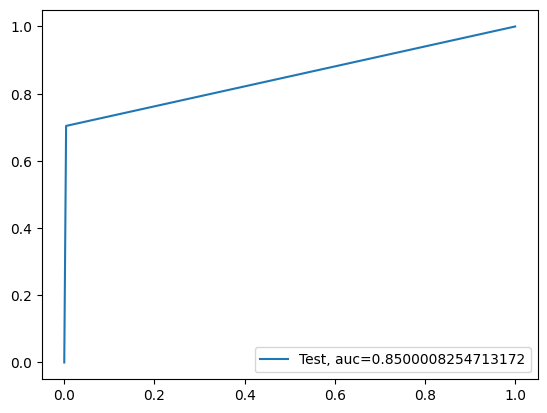

Time Taken by Model: 242.96860814094543
--------------------------------------------------------------------------------


In [58]:
print("Decision Tree Models with gini & entropy criteria")

start_time = time.time()

df_Results = buildAndRunTreeModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_ADASYN,
    y_train_ADASYN,
    X_test,
    y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

XGBoost Model
Model Accuracy: 0.999350432752234
Confusion Matrix


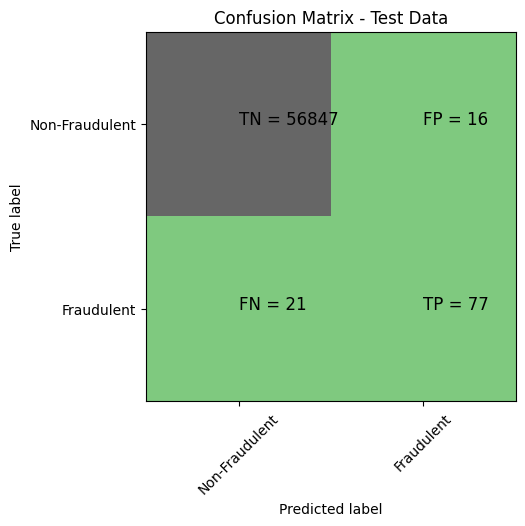

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.83      0.79      0.81        98

    accuracy                           1.00     56961
   macro avg       0.91      0.89      0.90     56961
weighted avg       1.00      1.00      1.00     56961

XGBoost roc_value: 0.9696561230052754
XGBoost threshold: 0.00012316476204432547
ROC for the test dataset: 97.0%


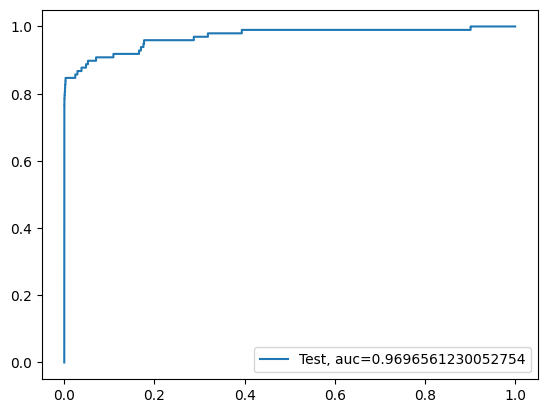

Time Taken by Model: 8.687254428863525
--------------------------------------------------------------------------------


In [59]:
print("XGBoost Model")

start_time = time.time()

df_Results = buildAndRunXGBoostModels(
    df_Results,
    Data_Imbalance_Handling,
    X_train_ADASYN,
    y_train_ADASYN,
    X_test,
    y_test
)

print("Time Taken by Model:", time.time() - start_time)
print("-"*80)

In [60]:
df_Results

,Methodology,Model,Accuracy,roc_value,threshold
0,RepeatedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998262,0.531862,0.499257
1,RepeatedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.999105,0.882563,0.106704
2,RepeatedKFold Cross Validation,KNN,0.999280,0.888725,0.200000
3,RepeatedKFold Cross Validation,Tree Model with gini criteria,0.999087,0.893667,1.000000
4,RepeatedKFold Cross Validation,Tree Model with entropy criteria,0.999034,0.878515,1.000000
5,RepeatedKFold Cross Validation,Random Forest,0.999491,0.937561,0.010000
6,RepeatedKFold Cross Validation,XGBoost,0.999456,0.952302,0.000104
7,StratifiedKFold Cross Validation,Logistic Regression with L2 Regularisation,0.998280,0.611162,0.499392
8,StratifiedKFold Cross Validation,Logistic Regression with L1 Regularisation,0.998754,0.889076,0.021087
9,StratifiedKFold Cross Validation,KNN,0.999192,0.805746,0.200000


## Results for ADASYN Oversampling with StratifiedKFold:
Looking at Accuracy and ROC value we have XGBoost which has provided best results for ADASYN Oversampling with StratifiedKFold technique

## Overall conclusion after running the models on Oversampled data :
Looking at above results it seems XGBOOST model with Random Oversampling with StratifiedKFold CV has provided the best results under the category of
all oversampling techniques. So we will try to tune the hyperparameters of this model to get best results.

## Hyperparameter Tuning

In [61]:
# Performing Hyperparameter tuning

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_test = {
    'max_depth': range(3, 10, 2),
    'min_child_weight': range(1, 6, 2),
    'n_estimators': range(60, 130, 150),
    'learning_rate': [0.05, 0.1, 0.125, 0.15, 0.2],
    'gamma': [i/10.0 for i in range(0,5)],
    'subsample': [i/10.0 for i in range(7,10)],
    'colsample_bytree': [i/10.0 for i in range(7,10)]
}

gsearch1 = RandomizedSearchCV(
    estimator=XGBClassifier(
        base_score=0.5,
        booster='gbtree',
        colsample_bylevel=1,
        colsample_bynode=1,
        max_delta_step=0,
        missing=None,
        n_jobs=-1,
        objective='binary:logistic',
        random_state=42,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=1,
        seed=None,
        verbosity=1
    ),
    param_distributions=param_test,
    n_iter=5,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5
)

gsearch1.fit(X_train_ADASYN, y_train_ADASYN)

gsearch1.cv_results_, gsearch1.best_params_, gsearch1.best_score_

C:\Users\Saksham Kaushik\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


({'mean_fit_time': array([43.26478148, 53.69362645, 44.69762621, 30.62669291, 28.95997047]),
  'std_fit_time': array([0.36710333, 0.45354639, 0.29555909, 6.94768393, 0.19285683]),
  'mean_score_time': array([0.1634016 , 0.05499539, 0.0868505 , 0.03168464, 0.01409631]),
  'std_score_time': array([0.13488106, 0.00967456, 0.00580553, 0.0247795 , 0.00204004]),
  'param_subsample': masked_array(data=[0.9, 0.7, 0.9, 0.7, 0.8],
               mask=[False, False, False, False, False],
         fill_value=1e+20),
  'param_n_estimators': masked_array(data=[60, 60, 60, 60, 60],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_min_child_weight': masked_array(data=[1, 1, 3, 1, 1],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_max_depth': masked_array(data=[3, 7, 3, 3, 5],
               mask=[False, False, False, False, False],
         fill_value=999999),
  'param_learning_rate': masked_array(data=[0.2, 

In [62]:
# Creating XGBoost model with selected hyperparameters
from xgboost import XGBClassifier

clf = XGBClassifier(
    base_score=0.5,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=0.7,
    gamma=0.2,
    learning_rate=0.125,
    max_delta_step=0,
    max_depth=7,
    min_child_weight=5,
    missing=np.nan,
    n_estimators=60,
    n_jobs=1,
    objective='binary:logistic',
    random_state=42,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=0.8,
    verbosity=1
)

# fit on the dataset
clf.fit(X_train_ADASYN, y_train_ADASYN)

XGB_test_score = clf.score(X_test, y_test)

print("Model Accuracy:", XGB_test_score)

# Probabilities for each class
XGB_probs = clf.predict_proba(X_test)[:,1]

# Calculate ROC AUC
from sklearn.metrics import roc_auc_score, roc_curve

XGB_roc_value = roc_auc_score(y_test, XGB_probs)

print("XGBoost ROC Value:", XGB_roc_value)

fpr, tpr, thresholds = roc_curve(y_test, XGB_probs)

threshold = thresholds[np.argmax(tpr - fpr)]

print("XGBoost threshold:", threshold)

Model Accuracy: 0.9981039658713857
XGBoost ROC Value: 0.9730682804750551
XGBoost threshold: 0.061171617


In [63]:
import joblib
joblib.dump(clf, "xgboost_fraud_model.pkl")

['xgboost_fraud_model.pkl']